# <span style="color:#0097b2">0. Data</span>
[Back to TOC](#toc)

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Libraries Importation</h3>

In [8]:
import os
import sys
import warnings
from scipy.stats import zscore
from sklearn.cluster import DBSCAN

import sys
sys.path.append('../')

# Suppress warnings
warnings.filterwarnings('ignore')

### Basic Libraries
import numpy as np
import pandas as pd

### Sklearn
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [9]:
#FUNÇOES

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
from PIL import Image
import urllib
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import silhouette_score, confusion_matrix
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import umap
import math

def set_plot_properties(ax, x_label, y_label, y_lim=[]):
    """
    Set properties of a plot axis.

    Args:
        ax (matplotlib.axes.Axes): The axis object of the plot.
        x_label (str): The label for the x-axis.
        y_label (str): The label for the y-axis.
        y_lim (list, optional): The limits for the y-axis. Defaults to [].

    Returns:
        None
    """
    ax.set_xlabel(x_label)  # Set the label for the x-axis
    ax.set_ylabel(y_label)  # Set the label for the y-axis
    if len(y_lim) != 0:
        ax.set_ylim(y_lim)  # Set the limits for the y-axis if provided


def plot_inertia_and_silhouette(data, k_min=2, k_max=15):
    """
    Plot the inertia (dispersion) and silhouette score for different numbers of clusters.

    Args:
        data (numpy.ndarray or pandas.DataFrame): The input data for clustering.
        k_min (int, optional): The minimum number of clusters to evaluate. Defaults to 2.
        k_max (int, optional): The maximum number of clusters to evaluate. Defaults to 15.

    Returns:
        None
    """
    dispersions = []
    scores = []

    k_clusters = range(k_min, k_max + 1)

    for k in k_clusters:
        kmeans = KMeans(n_clusters=k, random_state=0).fit(data)
        dispersions.append(kmeans.inertia_)  # Calculate the dispersion (inertia) for each number of clusters
        kmeans.predict(data)
        scores.append(silhouette_score(data, kmeans.labels_, metric='euclidean'))  # Calculate the silhouette score

    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.plot(k_clusters, dispersions, marker='o')  # Plot the inertia (dispersion)
    set_plot_properties(ax1, 'Number of clusters', 'Dispersion (inertia)')
    ax2.plot(k_clusters, scores, marker='o')  # Plot the silhouette score
    set_plot_properties(ax2, 'Number of clusters', 'Silhouette score')

    plt.show()


def plot_dendrogram(data, linkage_method, cut_line=None):
    """
    Plot a dendrogram for hierarchical clustering.

    Args:
        data (numpy.ndarray or pandas.DataFrame): The input data for clustering.
        linkage_method (str): The linkage method used for clustering.
        cut_line (float, optional): The threshold value to cut the dendrogram. Defaults to None.

    Returns:
        None
    """
    # Fit the AgglomerativeClustering model
    model = AgglomerativeClustering(linkage=linkage_method, distance_threshold=0, n_clusters=None).fit(data)

    # Create the plot
    fig, ax = plt.subplots()
    plt.title('Hierarchical Clustering Dendrogram')

    # Create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # Leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    # Create the linkage matrix
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)

    # Plot the dendrogram
    dendrogram(linkage_matrix, truncate_mode='level', p=50)

    # Add a cut line if provided
    if cut_line is not None:
        plt.axhline(y=cut_line, color='black', linestyle='-')

    # Display the plot
    plt.show()


def plot_umap_projections(people, cluster_columns, n_components=2, random_state=42):
    """
    Generates UMAP projections for multiple clustering methods and plots them in a grid.

    Parameters:
    people (DataFrame): The input data containing the features and cluster assignments.
    cluster_columns (list of str): The list of column names containing cluster assignments for each method.
    n_components (int): Number of dimensions for UMAP projection. Default is 2.
    random_state (int): Random state for UMAP. Default is 42.
    """
    # Check if at least one cluster column is provided
    if len(cluster_columns) < 1:
        raise ValueError("At least one cluster column must be provided.")

    # Determine the layout of subplots
    num_plots = len(cluster_columns)
    num_rows = math.ceil(math.sqrt(num_plots))
    num_cols = math.ceil(num_plots / num_rows)

    # Create the subplots
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(16, 12))
    axs = axs.flatten()  # Flatten the array of axes

    for i, cluster_column in enumerate(cluster_columns):
        # Check if the necessary columns are present in the dataframe
        if cluster_column not in people.columns:
            raise ValueError(f"Cluster column '{cluster_column}' not found in the data.")

        # Separate features and clusters
        features = people.drop(columns=[cluster_column])
        clusters = people[cluster_column]

        # Perform UMAP
        reducer = umap.UMAP(n_components=n_components, random_state=random_state)
        umap_embedding = reducer.fit_transform(features)

        # Plot the UMAP embedding
        scatter = axs[i].scatter(
            umap_embedding[:, 0], umap_embedding[:, 1],
            c=clusters, cmap='Spectral', s=5
        )
        axs[i].set_title(f'UMAP projection of {cluster_column}')
        axs[i].set_xlabel('UMAP 1')
        axs[i].set_ylabel('UMAP 2')

        # Add a color bar to each subplot
        cbar = plt.colorbar(scatter, ax=axs[i], boundaries=np.arange(clusters.nunique() + 1) - 0.5)
        cbar.set_ticks(np.arange(clusters.nunique()))

    # Remove any unused subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    # Adjust layout
    plt.tight_layout()
    plt.show()


def groupby_mean(data, variable, n_features=30):
    """
    Group the data by a variable and calculate the mean for each group.

    Args:
        data (pandas.DataFrame): The input data.
        variable (str): The variable used for grouping.
        n_features (int, optional): The number of features to include in the result. Defaults to 30.

    Returns:
        pandas.DataFrame: The transposed DataFrame containing the mean values for each group.
    """
    # Group the data by the specified variable and calculate the mean for each group
    grouped_data = data.groupby(variable).mean()

    # Select the first n_features + 1 columns (including the variable column) and transpose the DataFrame
    result = grouped_data.iloc[:, :n_features + 1].T

    # Return the transposed DataFrame
    return result

In [10]:
def correlation_matrix(data, threshold, x, y):

    """
    correlation_matrix plots a Pearson correlation matrix heatmap for numerical features in a dataset,
    displaying correlation values only when their absolute value exceeds a given
    threshold. We used it to analyse the correlation between our numerical features in EDA.

    Parameters:
    data : Input dataset containing numerical variables.
    
    threshold : Minimum absolute correlation value required for a cell to be annotated

    Returns: None, displays a correlation heatmap.
    """
    
    corr = data.corr(method="pearson")
    corr = corr.round(2)

    mask_annot = np.absolute(corr.values) >= threshold

    annot = np.where(mask_annot, corr.values, np.full(corr.shape,"")) 

    fig = plt.figure(figsize=(x, y))

    # Plotting the heatmap of the correlation matrix
    sns.heatmap(data=corr, 
                annot=annot, # Specifing custom annotation
                fmt='s', # The annotation matrix now has strings, so we need to explicitly say this
                vmin=-1, vmax=1, 
                center=0,
                square=True, # Make each cell square-shaped
                linewidths=.5, # Adding lines between cells
                cmap='PiYG' # Diverging color map
                )

    plt.show()


## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Data Importation</h3>

In [11]:
people = pd.read_csv("../data/cleaned_data/clustering_data_cleaned.csv", index_col = 'Loyalty#')

In [12]:
people

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Marital_Married,Marital_Single,Location__0,Location__1,Location__2,Location__3,Location__4,Location__5,Location__6,Location__7
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,1,0,0,1,0,0,0,0,0,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,1,0,0,0,0,0,0,1,0,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,1,0,0,0,0,1,0,0,0,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,1,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,0.0,0.0,...,1,0,0,0,0,0,1,0,0,0
999996,34148.0,5780.18,0,0,0.0,0,2018,9,0.0,0.0,...,0,1,0,1,0,0,0,0,0,0
999997,34148.0,5780.18,0,0,0.0,0,2020,1,0.0,0.0,...,1,0,0,0,0,1,0,0,0,0


In [13]:
len(people)

16715

In [14]:
people.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16715 entries, 100011 to 999999
Data columns (total 63 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Income                          16715 non-null  float64
 1   Customer Lifetime Value         16715 non-null  float64
 2   EnrollmentType                  16715 non-null  int64  
 3   rejoined_program                16715 non-null  int64  
 4   Days_in_prog                    16715 non-null  float64
 5   Cancelled_program               16715 non-null  int64  
 6   Enrollment_year                 16715 non-null  int64  
 7   Enrollment_month                16715 non-null  int64  
 8   TotalFlights                    16715 non-null  float64
 9   TotalDistance                   16715 non-null  float64
 10  TotalPointsAccumulated          16715 non-null  float64
 11  TotalPointsRedeemed             16715 non-null  float64
 12  Flights_per_day                

In [15]:
people

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Marital_Married,Marital_Single,Location__0,Location__1,Location__2,Location__3,Location__4,Location__5,Location__6,Location__7
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,1,0,0,1,0,0,0,0,0,0
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,0,1,0,0,0,0,1,0,0,0
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,1,0,0,0,0,0,0,1,0,0
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,1,0,0,0,0,1,0,0,0,0
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,1,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,0.0,0.0,...,1,0,0,0,0,0,1,0,0,0
999996,34148.0,5780.18,0,0,0.0,0,2018,9,0.0,0.0,...,0,1,0,1,0,0,0,0,0,0
999997,34148.0,5780.18,0,0,0.0,0,2020,1,0.0,0.0,...,1,0,0,0,0,1,0,0,0,0


In [16]:
people1 = people.copy()

In [17]:
for column in people1.columns:
   if column.startswith('Total_Spend_Month_'):
       people1[column] = np.sqrt(people1[column])

In [18]:
people_st_scl = StandardScaler().fit_transform(people1)
people_mm_scl = MinMaxScaler().fit_transform(people1)
people_rb_scl = RobustScaler().fit_transform(people1)

# <span style="color:#0097b2">1. Modelling</span>
[Back to TOC](#toc)

## <h2 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Perspective 3: VALUE-BASED SEGMENTATION</h2>

Prepare the data

### Perspective 2 — Engagement Features

In this perspective, we analyze the **level of engagement** customers have with the loyalty program.  
Instead of focusing only on *who they are*, we start looking at **how they interact with the program over time**.

We selected the following variables:

```python
engagement_features = [
    "Days_in_prog",
    "RecencyInMonths",
    "Flights_per_day",
    "PctFlightsWithCompanions",
    "PctPointsSpent"
]


In [19]:
# Perspective 2 — Engagement Features
engagement_features = [
    "Days_in_prog",
    "RecencyInMonths",
    "Flights_per_day",
    "PctFlightsWithCompanions",
    "PctPointsSpent"
]

### Preparing the Engagement Dataset

Now that we defined the engagement variables, we extract them from the main dataset to build a dedicated clustering view.

```python
customer_engagement = people[engagement_features].copy()


In [20]:
# Prepare data
customer_engagement = people[engagement_features].copy()

In [21]:
# First look at distributions
customer_engagement.describe()

,Days_in_prog,RecencyInMonths,Flights_per_day,PctFlightsWithCompanions,PctPointsSpent
count,16715.000000,16715.000000,16715.000000,16715.000000,16715.000000
mean,1092.108525,92.712750,0.131797,0.231549,0.278849
std,743.998780,286.356775,0.075674,0.133744,0.337946
min,0.000000,1.018397,0.000000,0.000000,0.000000
25%,361.000000,1.018397,0.066575,0.161177,0.000000
50%,1015.000000,1.018397,0.151050,0.234242,0.215097
75%,1745.000000,2.003942,0.188311,0.304348,0.417737
max,2465.000000,999.000000,0.492603,1.052632,7.674566


## Correlation Matrix

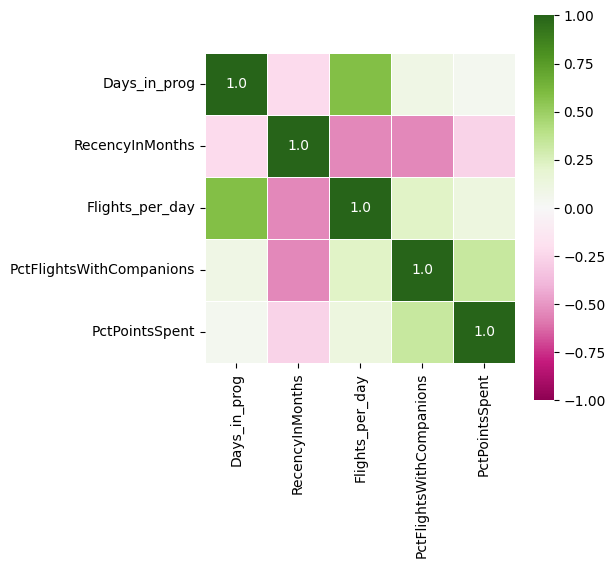

In [22]:
correlation_matrix(customer_engagement, 0.7, 5, 5)

Feature selection check — Engagement perspective

To validate our feature choice, we computed a Pearson correlation matrix.
The engagement variables show **only moderate correlations** and no values close to ±1, meaning:

* none of the variables are redundant or simple duplicates,
* each feature contributes distinct information about customer engagement.

Therefore, the selected features
**(Days_in_prog, Recency, Flights_per_day, Companion % and Points %)**
are appropriate for clustering and we keep all of them.


In [23]:
st_scaler = StandardScaler().set_output(transform="pandas")
rb_scaler = RobustScaler().set_output(transform="pandas")
mm_scaler = MinMaxScaler().set_output(transform="pandas")

customer_engagement_st = st_scaler.fit_transform(customer_engagement)
customer_engagement_rb = rb_scaler.fit_transform(customer_engagement)
customer_engagement_mm = mm_scaler.fit_transform(customer_engagement)


## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Standard Scaling</h3>

### K-Means

Choosing the number of clusters (Engagement perspective)

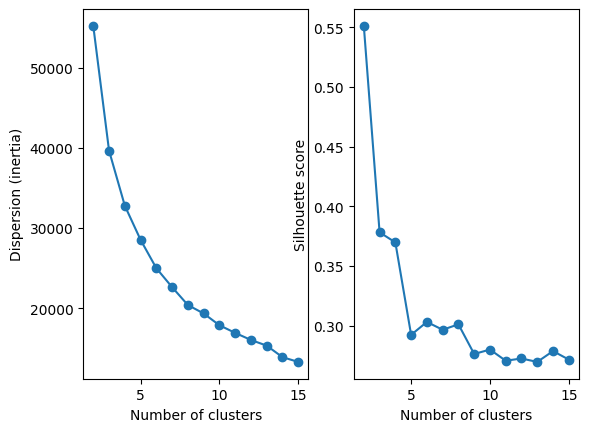

In [24]:
plot_inertia_and_silhouette(customer_engagement_st)

From the inertia (elbow) and silhouette plots, we see:

- A strong improvement from **K = 2 → 3**
- A smaller but meaningful gain at **K = 4**
- After K ≥ 5, inertia decreases slowly and silhouette becomes unstable

To avoid over-fragmenting the data while keeping clusters interpretable,  
we test **K = 3 and K = 4** and compare their business meaning.

In [25]:
kmeans_st_scl_3 = KMeans(n_clusters=3, random_state=42).fit(customer_engagement_st)
people['st_scaled_km_cluster3'] = kmeans_st_scl_3.predict(customer_engagement_st)

kmeans_st_scl_4 = KMeans(n_clusters=4, random_state=42).fit(customer_engagement_st)
people['st_scaled_km_cluster4'] = kmeans_st_scl_4.predict(customer_engagement_st)


In [26]:
tmp = customer_engagement_st.copy()
tmp['st_scaled_km_cluster3'] = people['st_scaled_km_cluster3']

groupby_mean(
    tmp,
    'st_scaled_km_cluster3',
    n_features=5
)


st_scaled_km_cluster3,0,1,2
Days_in_prog,-0.966078,-0.685349,0.626681
RecencyInMonths,-0.312140,3.164983,-0.317952
Flights_per_day,-0.733379,-1.715402,0.659404
PctFlightsWithCompanions,0.244712,-1.708248,0.130466
PctPointsSpent,0.115400,-0.816761,0.063245


In [27]:
tmp = customer_engagement_st.copy()
tmp['st_scaled_km_cluster4'] = people['st_scaled_km_cluster4']

groupby_mean(
    tmp,
    'st_scaled_km_cluster4',
    n_features=5
)


st_scaled_km_cluster4,0,1,2,3
Days_in_prog,-0.720664,-0.685349,-0.936327,0.669234
RecencyInMonths,-0.312548,3.164983,-0.312517,-0.318059
Flights_per_day,-0.592271,-1.715402,-0.636692,0.675053
PctFlightsWithCompanions,1.190446,-1.708248,-0.072278,0.121426
PctPointsSpent,1.850794,-0.816761,-0.404801,0.027136


Choosing K for Engagement Clustering in Standard Scaling (K-Means)

We compared K = 3 and K = 4 using the standardized engagement features.

K = 3

Captures the main structure, but mixes different types of low-engagement customers together.

K = 4

Separates the customers more clearly into:

dormant / almost inactive

low-engagement

moderate users

highly engaged members

Decision

K = 4 gives clearer, more interpretable behavioral groups, so we continue with this solution.

### Hierarchichal - Ward

In [28]:
print("customer_engagement columns:")
print(list(customer_engagement.columns))

print("\ncustomer_engagement_st columns:")
print(list(customer_engagement_st.columns))


customer_engagement columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']

customer_engagement_st columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']


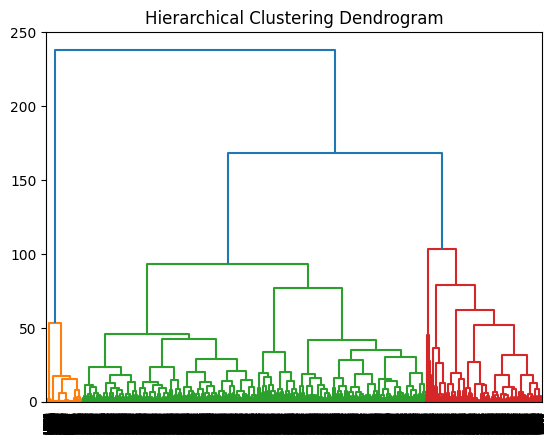

In [29]:
plot_dendrogram(customer_engagement_st, 'ward')

Hierarchical clustering — testing Ward solutions (k = 2, 3, 4)

With the dendrogram and silhouette trends, we focused on a small set of
promising cluster solutions. Ward’s method suggested that the main
structure emerges between **2 and 4 groups**, so we test those values to
compare stability and interpretability.

We now compute hierarchical clustering for:

* **k = 2** → coarse segmentation
* **k = 3** → clearer behavioral separation
* **k = 4** → more granular, but still interpretable

The goal is to choose the smallest *k* that still produces meaningful,
well-separated engagement profiles.


In [30]:
# Hierarchical clustering (Ward) on engagement features
for k in [2, 3, 4]:
    people[f'st_scaled_ward_cluster{k}'] = AgglomerativeClustering(
        linkage='ward',
        n_clusters=k
    ).fit_predict(customer_engagement_st)


In [31]:
for k in [2, 3, 4]:
    tmp = customer_engagement_st[engagement_features].copy()
    tmp[f'st_scaled_ward_cluster{k}'] = people[f'st_scaled_ward_cluster{k}']

    print(f"\nWard clustering – k = {k}")
    display(
        groupby_mean(
            tmp,
            f'st_scaled_ward_cluster{k}',
            n_features=5
        )
    )



Ward clustering – k = 2


st_scaled_ward_cluster2,0,1
Days_in_prog,0.068409,-0.685349
RecencyInMonths,-0.315915,3.164983
Flights_per_day,0.171224,-1.715402
PctFlightsWithCompanions,0.170510,-1.708248
PctPointsSpent,0.081526,-0.816761



Ward clustering – k = 3


st_scaled_ward_cluster3,0,1,2
Days_in_prog,-1.056318,-0.685349,0.445228
RecencyInMonths,-0.311181,3.164983,-0.317501
Flights_per_day,-1.057894,-1.715402,0.583018
PctFlightsWithCompanions,0.250386,-1.708248,0.143749
PctPointsSpent,0.090378,-0.816761,0.078560



Ward clustering – k = 4


st_scaled_ward_cluster4,0,1,2,3
Days_in_prog,0.445228,-0.685349,-1.051080,-1.160838
RecencyInMonths,-0.317501,3.164983,-0.311305,-0.308695
Flights_per_day,0.583018,-1.715402,-1.044913,-1.316938
PctFlightsWithCompanions,0.143749,-1.708248,0.197036,1.315041
PctPointsSpent,0.078560,-0.816761,-0.168656,5.259657


In [32]:
print("customer_engagement columns:")
print(list(customer_engagement.columns))

print("\ncustomer_engagement_st columns:")
print(list(customer_engagement_st.columns))


customer_engagement columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']

customer_engagement_st columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']


Ward clustering — choosing k

We evaluated k = 2, 3, 4.

k = 2 → too coarse (mainly low vs. high engagement).

k = 4 → adds complexity without clearly distinct new patterns.

k = 3 → provides the cleanest, most interpretable separation.

We therefore select k = 3.

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">MinMax Scaling</h3>

### K-Means

In [33]:
print("customer_engagement columns:")
print(list(customer_engagement.columns))

print("\ncustomer_engagement_st columns:")
print(list(customer_engagement_mm.columns))


customer_engagement columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']

customer_engagement_st columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']


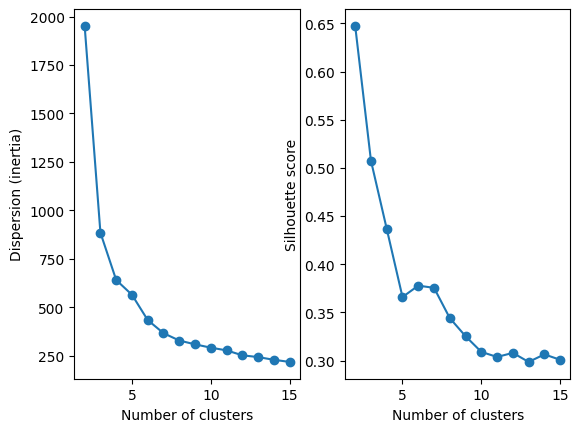

In [34]:
plot_inertia_and_silhouette(customer_engagement_mm)

In [35]:
# K-Means on engagement features (Min-Max Scaled)

kmeans_mm_3 = KMeans(n_clusters=3, random_state=42).fit(customer_engagement_mm)
people['mm_scaled_km_cluster3'] = kmeans_mm_3.predict(customer_engagement_mm)

kmeans_mm_4 = KMeans(n_clusters=4, random_state=42).fit(customer_engagement_mm)
people['mm_scaled_km_cluster4'] = kmeans_mm_4.predict(customer_engagement_mm)

kmeans_mm_5 = KMeans(n_clusters=5, random_state=42).fit(customer_engagement_mm)
people['mm_scaled_km_cluster5'] = kmeans_mm_5.predict(customer_engagement_mm)

kmeans_mm_6 = KMeans(n_clusters=6, random_state=42).fit(customer_engagement_mm)
people['mm_scaled_km_cluster6'] = kmeans_mm_6.predict(customer_engagement_mm)


In [36]:
for k in [3, 4, 5, 6]:
    tmp = customer_engagement_mm.copy()
    tmp[f'mm_scaled_km_cluster{k}'] = people[f'mm_scaled_km_cluster{k}']

    print(f"\nK-means MinMax — k = {k}")
    display(
        groupby_mean(
            tmp,
            f'mm_scaled_km_cluster{k}',
            n_features=5
        )
    )



K-means MinMax — k = 3


mm_scaled_km_cluster3,0,1,2
Days_in_prog,0.718728,0.236197,0.208322
RecencyInMonths,0.000738,1.000000,0.001733
Flights_per_day,0.364766,0.004040,0.222851
PctFlightsWithCompanions,0.238090,0.002934,0.245185
PctPointsSpent,0.039288,0.000370,0.040561



K-means MinMax — k = 4


mm_scaled_km_cluster4,0,1,2,3
Days_in_prog,0.434147,0.236197,0.126131,0.807157
RecencyInMonths,0.000900,1.000000,0.002219,0.000662
Flights_per_day,0.360114,0.004040,0.147578,0.362541
PctFlightsWithCompanions,0.237770,0.002934,0.247831,0.239798
PctPointsSpent,0.039609,0.000370,0.040964,0.039278



K-means MinMax — k = 5


mm_scaled_km_cluster5,0,1,2,3,4
Days_in_prog,0.434147,0.930116,0.126131,0.807157,0.112186
RecencyInMonths,0.000900,1.000000,0.002219,0.000662,1.000000
Flights_per_day,0.360114,0.000000,0.147578,0.362541,0.004762
PctFlightsWithCompanions,0.237770,0.000000,0.247831,0.239798,0.003458
PctPointsSpent,0.039609,0.000000,0.040964,0.039278,0.000436



K-means MinMax — k = 6


mm_scaled_km_cluster6,0,1,2,3,4,5
Days_in_prog,0.314370,0.930116,0.113867,0.859945,0.112186,0.588849
RecencyInMonths,0.000779,1.000000,0.002512,0.000615,1.000000,0.000951
Flights_per_day,0.351221,0.000000,0.113474,0.363407,0.004762,0.358469
PctFlightsWithCompanions,0.234756,0.000000,0.252120,0.239198,0.003458,0.239781
PctPointsSpent,0.038989,0.000000,0.041602,0.039182,0.000436,0.039808


Choosing k for K-Means (Min-Max scaled)

Across the Min-Max scaled solutions (k = 3, 4, 5, 6), cluster structures are quite similar:
clusters mainly differ by engagement intensity (tenure, flights, points spent).

k = 3 already separates: low, medium, and high engagement.

k = 4 adds only a minor split (medium users split into two very similar groups).

k = 5–6 produce small, overly specific clusters without new business meaning.

We therefore keep k = 3 for the Min-Max scaling, since it gives the clearest, interpretable segmentation with minimal redundancy.

### Hierarchichal - Ward

In [37]:
print("customer_engagement columns:")
print(list(customer_engagement.columns))

print("\ncustomer_engagement_st columns:")
print(list(customer_engagement_mm.columns))


customer_engagement columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']

customer_engagement_st columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']


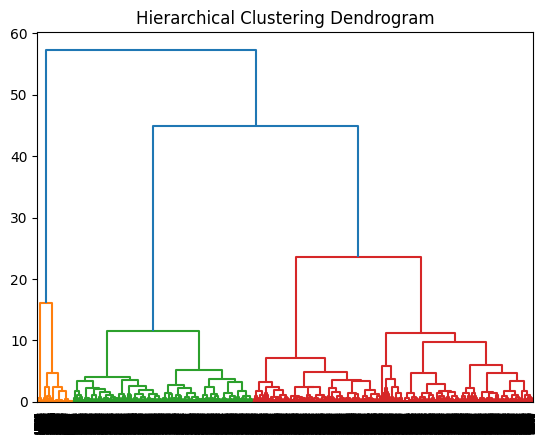

In [38]:
plot_dendrogram(customer_engagement_mm, 'ward')

In [39]:
# Hierarchical clustering (Ward) on engagement features — Min-Max scaled
for k in [2, 3, 4, 8]:
    people[f'mm_scaled_ward_cluster{k}'] = AgglomerativeClustering(
        linkage='ward',
        n_clusters=k
    ).fit_predict(customer_engagement_mm)

In [40]:
# Inspect cluster profiles 
for k in [2, 3, 4, 8]:
    tmp = customer_engagement_mm.copy()
    tmp[f'mm_scaled_ward_cluster{k}'] = people[f'mm_scaled_ward_cluster{k}']

    print(f"\nWard (Min-Max) — k = {k}")
    display(
        groupby_mean(
            tmp,
            f'mm_scaled_ward_cluster{k}',
            n_features=5
        )
    )



Ward (Min-Max) — k = 2


mm_scaled_ward_cluster2,0,1
Days_in_prog,0.463693,0.236197
RecencyInMonths,0.001235,1.000000
Flights_per_day,0.293855,0.004040
PctFlightsWithCompanions,0.241635,0.002934
PctPointsSpent,0.039924,0.000370



Ward (Min-Max) — k = 3


mm_scaled_ward_cluster3,0,1,2
Days_in_prog,0.262678,0.236197,0.777773
RecencyInMonths,0.001610,1.000000,0.000649
Flights_per_day,0.248267,0.004040,0.365086
PctFlightsWithCompanions,0.244322,0.002934,0.237436
PctPointsSpent,0.040570,0.000370,0.038914



Ward (Min-Max) — k = 4


mm_scaled_ward_cluster4,0,1,2,3
Days_in_prog,0.236197,0.133986,0.777773,0.414660
RecencyInMonths,1.000000,0.002171,0.000649,0.000948
Flights_per_day,0.004040,0.154424,0.365086,0.359093
PctFlightsWithCompanions,0.002934,0.248338,0.237436,0.239580
PctPointsSpent,0.000370,0.040967,0.038914,0.040102



Ward (Min-Max) — k = 8


mm_scaled_ward_cluster8,0,1,2,3,4,5,6,7
Days_in_prog,0.414660,0.178324,0.075418,0.673562,0.942711,0.885959,0.115080,0.099230
RecencyInMonths,0.000948,0.001442,0.002980,0.000661,1.000000,0.000637,1.000000,0.002799
Flights_per_day,0.359093,0.239473,0.050133,0.363554,0.000000,0.366677,0.004733,0.084765
PctFlightsWithCompanions,0.239580,0.260564,0.493500,0.240018,0.000000,0.234755,0.003437,0.141778
PctPointsSpent,0.040102,0.041581,0.085567,0.038743,0.000000,0.039093,0.000433,0.023631


In [41]:
print("customer_engagement columns:")
print(list(customer_engagement.columns))

print("\ncustomer_engagement_st columns:")
print(list(customer_engagement_mm.columns))


customer_engagement columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']

customer_engagement_st columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']


Ward clustering (Min-Max) — choosing k

For Ward with Min-Max scaling, the structures are:

k = 2 → very coarse split (recent vs. non-recent customers)

k = 3–4 → clusters become interpretable and behaviorally distinct
(tenure vs. recency vs. flight intensity)

k = 8 → mostly fragments existing groups without adding clear insight

We retain k = 3 (and consider k = 4 as an alternative) because these solutions:

separate customers along meaningful engagement dimensions,

are stable, avoid over-fragmentation.

k = 8 is more granular, but does not translate into clearer business actions.

## <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">Robust Scaling</h3>

### K-Means

### Testing Different Values of K (Behavioral / Engagement Clustering)

We now evaluate how many clusters make sense for the *engagement* dimension.

First, we visualized inertia and silhouette scores:

```python
plot_inertia_and_silhouette(customer_engagement_rb)


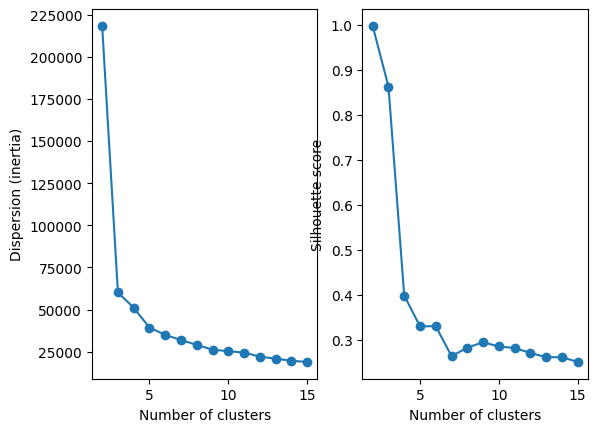

In [42]:
plot_inertia_and_silhouette(customer_engagement_rb)

### Running K-Means with Multiple K Values

To understand how the data behaves under different segmentation granularities,
we run K-Means repeatedly using several candidate values for **K**.


In [43]:
for k in [3, 4, 5]:
    kmeans_rb_scl = KMeans(n_clusters=k, random_state=42).fit(customer_engagement_rb)
    people[f"rb_scaled_km_cluster{k}"] = kmeans_rb_scl.predict(customer_engagement_rb)


In [44]:
# Inspect cluster profiles
for k in [3, 4, 5]:
    tmp = customer_engagement_rb.copy()
    tmp[f'rb_scaled_km_cluster{k}'] = people[f'rb_scaled_km_cluster{k}']

    print(f"\nK-means Robust — k = {k}")
    display(
        groupby_mean(
            tmp,
            f'rb_scaled_km_cluster{k}',
            n_features=5
        )
    )


K-means Robust — k = 3


rb_scaled_km_cluster3,0,1,2
Days_in_prog,0.109881,-0.312699,-0.264541
RecencyInMonths,0.539493,1012.618667,15.849056
Flights_per_day,-0.022996,-1.224461,-0.641366
PctFlightsWithCompanions,0.136629,-1.614532,0.219238
PctPointsSpent,0.218269,-0.508122,0.224594



K-means Robust — k = 4


rb_scaled_km_cluster4,0,1,2,3
Days_in_prog,0.113451,-0.312699,-0.281215,-0.233264
RecencyInMonths,0.467862,1012.618667,19.142905,10.067880
Flights_per_day,-0.018228,-1.224461,-0.804543,-0.439772
PctFlightsWithCompanions,0.137266,-1.614532,0.255999,0.140488
PctPointsSpent,0.218452,-0.508122,0.205626,0.232968



K-means Robust — k = 5


rb_scaled_km_cluster5,0,1,2,3,4
Days_in_prog,-0.094513,-0.312699,-0.281215,-0.233264,0.204900
RecencyInMonths,0.825773,1012.618667,19.142905,10.067880,0.310476
Flights_per_day,-0.307606,-1.224461,-0.804543,-0.439772,0.109021
PctFlightsWithCompanions,0.854110,-1.614532,0.255999,0.140488,-0.177955
PctPointsSpent,0.625392,-0.508122,0.205626,0.232968,0.039507


Choosing the number of clusters (Engagement perspective)

To decide the best value of K, we tested K-Means with K = 3, 4 and 5 using the engagement features.
Across all values, we consistently observed one clear segment of non-active customers (very high recency, almost no flights, almost no points spent). This shows that the clustering is capturing a real pattern in the data.

However, the structure of the remaining clusters changed:

K = 3 was too coarse — active customers with different engagement levels were mixed together.

K = 5 started to over-segment the data, creating clusters that were very similar to each other and harder to interpret.

K = 4 provided the best balance: it separates customers into four intuitive behavioral groups (inactive, low, moderate and high engagement) while remaining simple to explain from a business perspective.

For this reason, we continue with K = 4.

### Hierarchichal - Ward

### Hierarchical Clustering — Dendrogram (Ward Linkage)

To complement the K-Means analysis, we also explore the structure of the data
using **hierarchical clustering**.

In [45]:
print("customer_engagement columns:")
print(list(customer_engagement.columns))

print("\ncustomer_engagement_rb columns:")
print(list(customer_engagement_rb.columns))


customer_engagement columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']

customer_engagement_rb columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']


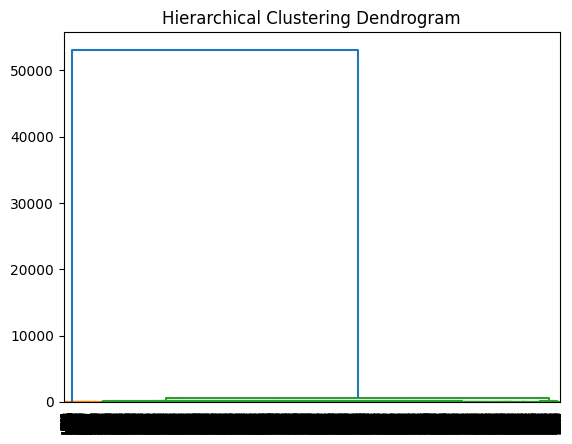

In [46]:
plot_dendrogram(customer_engagement_rb, 'ward')

### Using the Dendrogram to Select Candidate Cluster Counts

After inspecting the dendrogram generated with Ward linkage, we observed a few
large vertical jumps, suggesting that the data may naturally separate into a
small number of groups.

To evaluate those possibilities more systematically, we tested hierarchical
clustering with different values of \(k\):

In [47]:
for k in [3, 4, 5, 6]:
    people[f"rb_scaled_ward_cluster{k}"] = AgglomerativeClustering(
        linkage='ward',
        n_clusters=k
    ).fit_predict(customer_engagement_rb)

    print(f"K = {k}")
    display(groupby_mean(people, f"rb_scaled_ward_cluster{k}").head(10))


K = 3


rb_scaled_ward_cluster3,0,1,2
Income,36729.319945,37933.992749,37802.135120
Customer Lifetime Value,7724.694141,8329.786427,7944.757224
EnrollmentType,0.012465,0.027686,0.075159
rejoined_program,0.004155,0.014502,0.011605
Days_in_prog,639.908587,582.224786,1168.095123
Cancelled_program,0.914127,0.615689,0.031362
Enrollment_year,2018.577562,2017.800264,2018.280741
Enrollment_month,6.429363,7.259064,6.614465
TotalFlights,79.799169,0.000000,162.431051
TotalDistance,155498.484349,0.000000,325587.304179


K = 4


rb_scaled_ward_cluster4,0,1,2,3
Income,37802.135120,36302.316940,37168.317416,37933.992749
Customer Lifetime Value,7944.757224,7615.355246,7837.104354,8329.786427
EnrollmentType,0.075159,0.013661,0.011236,0.027686
rejoined_program,0.011605,0.002732,0.005618,0.014502
Days_in_prog,1168.095123,681.426230,597.224719,582.224786
Cancelled_program,0.031362,0.923497,0.904494,0.615689
Enrollment_year,2018.280741,2018.792350,2018.356742,2017.800264
Enrollment_month,6.614465,5.767760,7.109551,7.259064
TotalFlights,162.431051,104.440164,54.466011,0.000000
TotalDistance,325587.304179,205841.592896,103741.243539,0.000000


K = 5


rb_scaled_ward_cluster5,0,1,2,3,4
Income,37811.142625,37726.855204,37168.317416,37933.992749,36302.316940
Customer Lifetime Value,7952.564037,7879.512049,7837.104354,8329.786427,7615.355246
EnrollmentType,0.074638,0.079509,0.011236,0.027686,0.013661
rejoined_program,0.012453,0.004525,0.005618,0.014502,0.002732
Days_in_prog,1171.601052,1138.794441,597.224719,582.224786,681.426230
Cancelled_program,0.008817,0.219780,0.904494,0.615689,0.923497
Enrollment_year,2018.280609,2018.281836,2018.356742,2017.800264,2018.792350
Enrollment_month,6.611726,6.637363,7.109551,7.259064,5.767760
TotalFlights,163.739740,151.493730,54.466011,0.000000,104.440164
TotalDistance,328414.163114,301961.926568,103741.243539,0.000000,205841.592896


K = 6


rb_scaled_ward_cluster6,0,1,2,3,4,5
Income,37775.169425,37726.855204,38083.589523,37933.992749,36302.316940,37168.317416
Customer Lifetime Value,7936.496435,7879.512049,8074.253753,8329.786427,7615.355246,7837.104354
EnrollmentType,0.069258,0.079509,0.115385,0.027686,0.013661,0.011236
rejoined_program,0.008493,0.004525,0.042440,0.014502,0.002732,0.005618
Days_in_prog,1235.387006,1138.794441,688.511273,582.224786,681.426230,597.224719
Cancelled_program,0.007355,0.219780,0.019894,0.615689,0.923497,0.904494
Enrollment_year,2018.108309,2018.281836,2019.585544,2017.800264,2018.792350,2018.356742
Enrollment_month,6.587076,6.637363,6.798408,7.259064,5.767760,7.109551
TotalFlights,172.105639,151.493730,100.379708,0.000000,104.440164,54.466011
TotalDistance,344695.457727,301961.926568,205106.029310,0.000000,205841.592896,103741.243539


Using hierarchical clustering (Ward), we tested cut levels between 3 and 6 clusters. 

K = 4 produced the best structure: non-travellers were clearly separated, and the remaining customers formed intuitive engagement tiers (low, moderate, high).
Larger K values started to over-segment similar customers, while smaller K mixed distinct behaviors together.
Therefore, we selected Ward with K = 4 for the engagement perspective.

In [48]:
print("customer_engagement columns:")
print(list(customer_engagement.columns))

print("\ncustomer_engagement_rb columns:")
print(list(customer_engagement_rb.columns))


customer_engagement columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']

customer_engagement_rb columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']


In [49]:
people['rb_scaled_ward_cluster4'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 4
    ).fit_predict(customer_engagement_rb)

In [50]:
groupby_mean(people, 'rb_scaled_ward_cluster4')

rb_scaled_ward_cluster4,0,1,2,3
Income,37802.135120,36302.316940,37168.317416,37933.992749
Customer Lifetime Value,7944.757224,7615.355246,7837.104354,8329.786427
EnrollmentType,0.075159,0.013661,0.011236,0.027686
rejoined_program,0.011605,0.002732,0.005618,0.014502
Days_in_prog,1168.095123,681.426230,597.224719,582.224786
Cancelled_program,0.031362,0.923497,0.904494,0.615689
Enrollment_year,2018.280741,2018.792350,2018.356742,2017.800264
Enrollment_month,6.614465,5.767760,7.109551,7.259064
TotalFlights,162.431051,104.440164,54.466011,0.000000
TotalDistance,325587.304179,205841.592896,103741.243539,0.000000


In [51]:
print("customer_engagement columns:")
print(list(customer_engagement.columns))

print("\ncustomer_engagement_rb columns:")
print(list(customer_engagement_rb.columns))


customer_engagement columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']

customer_engagement_rb columns:
['Days_in_prog', 'RecencyInMonths', 'Flights_per_day', 'PctFlightsWithCompanions', 'PctPointsSpent']


# <span style="color:#0097b2">2. Filtering</span>
[Back to TOC](#toc)

### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(1) First-Examination</h3>

#### Cluster Visualization (Perspective 1 — Profile Features)

To visually assess the structure of the clusters, we projected the engagement features to 2-D using UMAP and overlaid the labels from each candidate model.

UMAP does not influence the clustering — it only helps us inspect whether clusters appear compact and well-separated.

Across models we observed:

Some configurations created partitions that overlapped strongly, suggesting that they were forcing splits without clear behavioral meaning.

Others formed more stable, compact regions, where customers with similar engagement patterns stayed together.

The most interpretable structures appeared when using:

StandardScaler — K-Means (K = 4)

Min-Max — K-Means (K = 3)

Robust — K-Means (K = 4)

Ward Hierarchical clustering with K = 3–4 (depending on the scaler)

These solutions consistently produced clusters that map naturally to business concepts such as inactive, low, moderate, and high engagement, while avoiding unnecessary fragmentation.


In [52]:
[col for col in people.columns if "km" in col or "ward" in col]


['st_scaled_km_cluster3',
 'st_scaled_km_cluster4',
 'st_scaled_ward_cluster2',
 'st_scaled_ward_cluster3',
 'st_scaled_ward_cluster4',
 'mm_scaled_km_cluster3',
 'mm_scaled_km_cluster4',
 'mm_scaled_km_cluster5',
 'mm_scaled_km_cluster6',
 'mm_scaled_ward_cluster2',
 'mm_scaled_ward_cluster3',
 'mm_scaled_ward_cluster4',
 'mm_scaled_ward_cluster8',
 'rb_scaled_km_cluster3',
 'rb_scaled_km_cluster4',
 'rb_scaled_km_cluster5',
 'rb_scaled_ward_cluster3',
 'rb_scaled_ward_cluster4',
 'rb_scaled_ward_cluster5',
 'rb_scaled_ward_cluster6']

In [53]:
clusters_km = [
    'st_scaled_km_cluster4',     # StandardScaler — K=4
    'mm_scaled_km_cluster3',     # Min-Max — K=3
    'rb_scaled_km_cluster4'      # Robust — K=4
]

In [54]:
eng_umap = customer_engagement.copy()

for c in clusters_km:
    eng_umap[c] = people[c]


In [55]:
[col for col in eng_umap.columns if "km" in col or "ward" in col]

['st_scaled_km_cluster4', 'mm_scaled_km_cluster3', 'rb_scaled_km_cluster4']

In [56]:
[col for col in eng_umap.columns]

['Days_in_prog',
 'RecencyInMonths',
 'Flights_per_day',
 'PctFlightsWithCompanions',
 'PctPointsSpent',
 'st_scaled_km_cluster4',
 'mm_scaled_km_cluster3',
 'rb_scaled_km_cluster4']

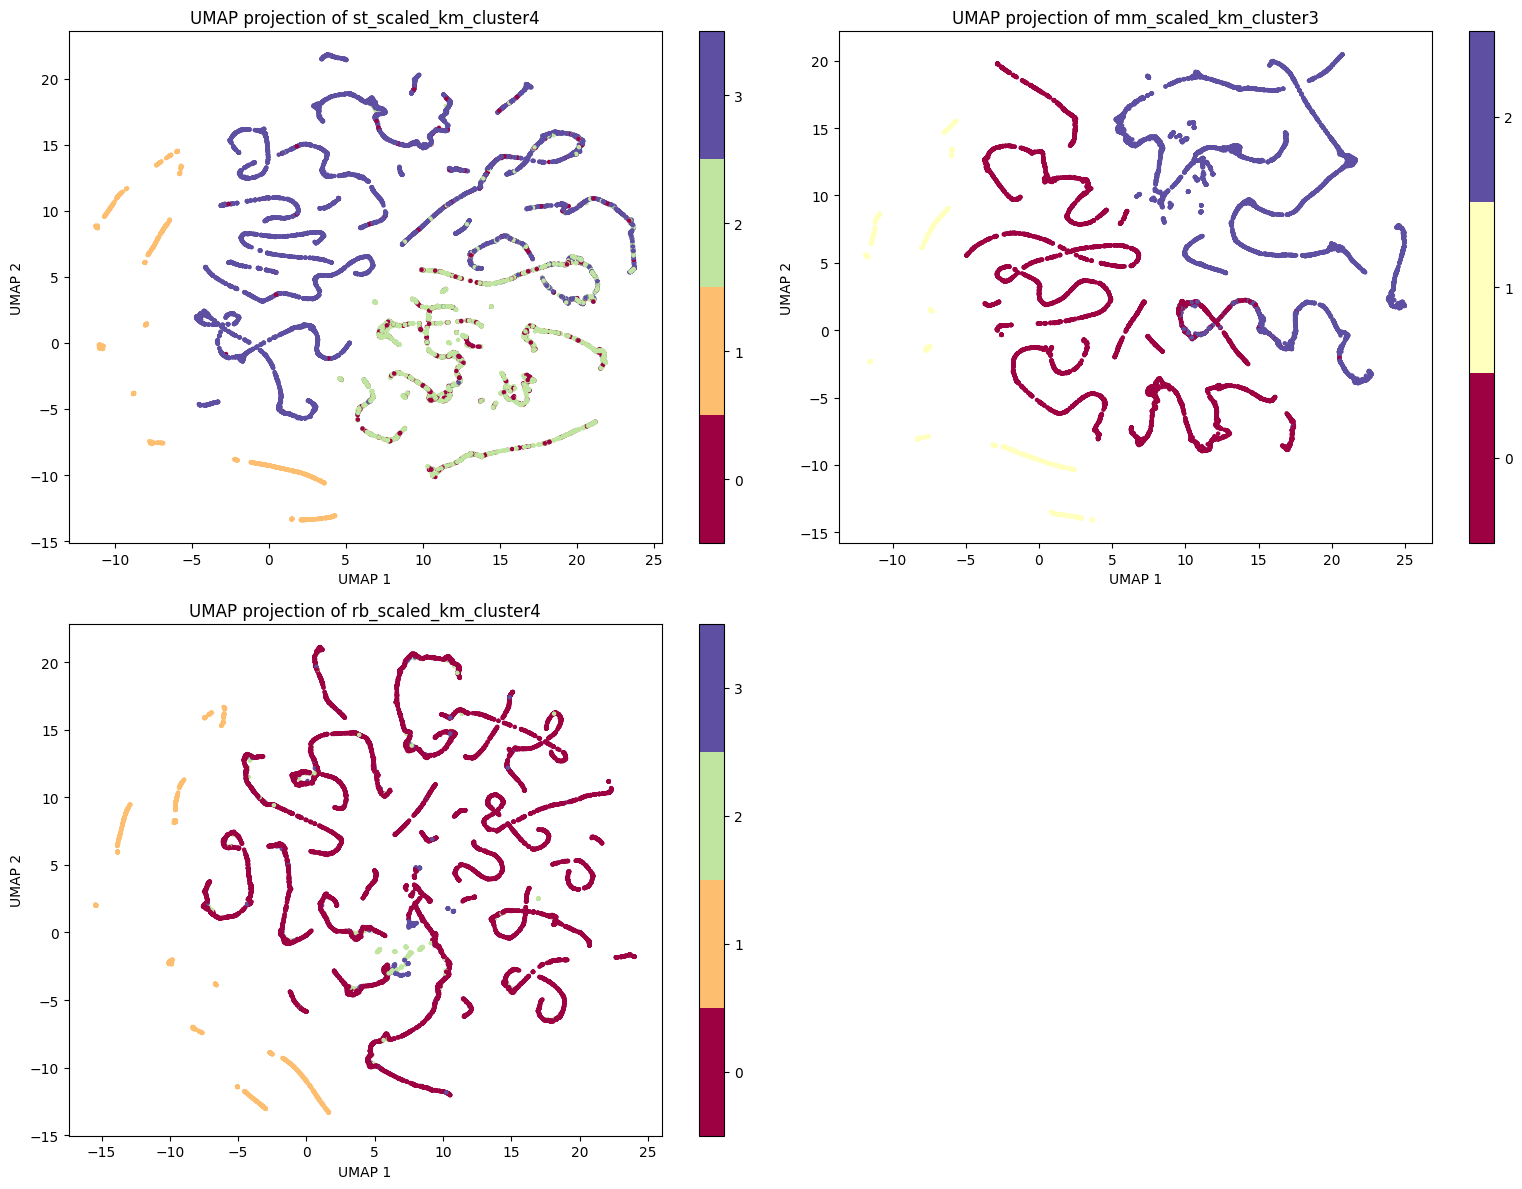

In [57]:
plot_umap_projections(eng_umap, clusters_km)

In [58]:
cluster_ward = [
    'st_scaled_ward_cluster3',
    'mm_scaled_ward_cluster3',
    'mm_scaled_ward_cluster4',
    'rb_scaled_ward_cluster4'
]

In [59]:
# Copy engagement data
eng_umap_ward = customer_engagement.copy()

# Attach Ward cluster labels
for c in cluster_ward:
    eng_umap_ward[c] = people[c]


In [60]:
[col for col in eng_umap_ward.columns if "km" in col or "ward" in col]

['st_scaled_ward_cluster3',
 'mm_scaled_ward_cluster3',
 'mm_scaled_ward_cluster4',
 'rb_scaled_ward_cluster4']

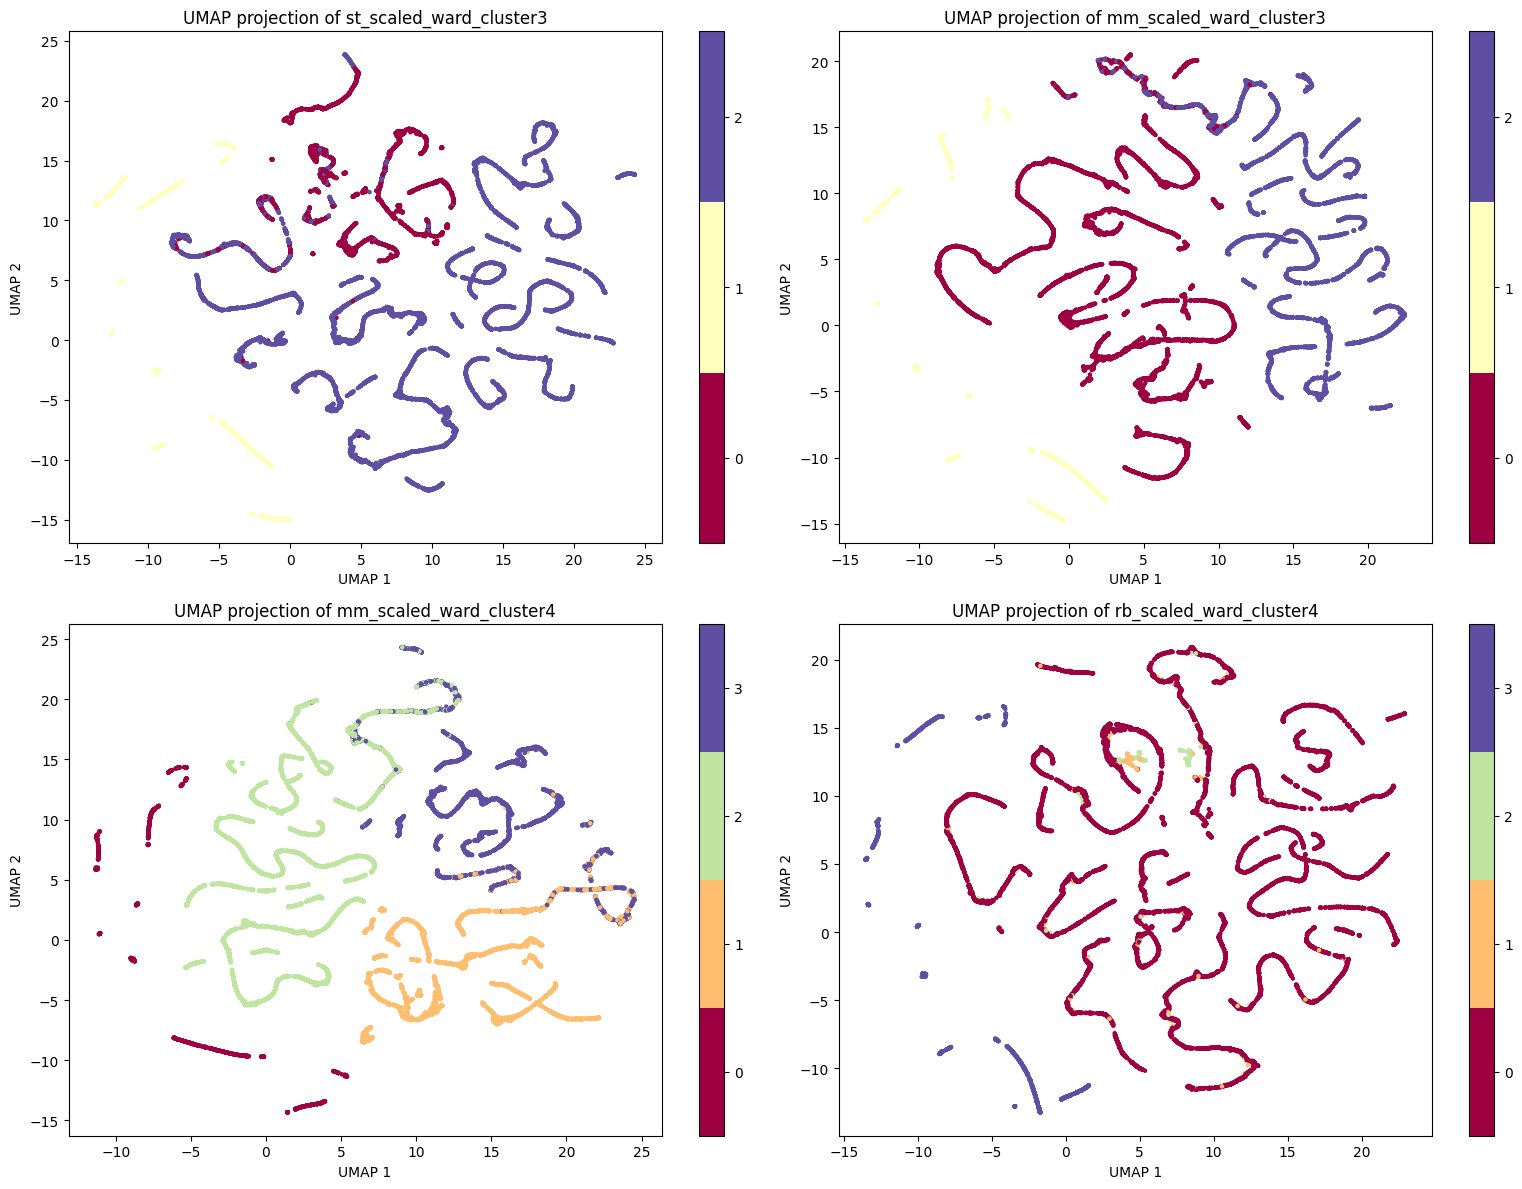

In [61]:
plot_umap_projections(eng_umap_ward, cluster_ward)

In [62]:
candidates = [
    'mm_scaled_km_cluster3',
    'mm_scaled_ward_cluster3',
    'mm_scaled_ward_cluster4',
    'rb_scaled_km_cluster4'
]

for c in candidates:
    tmp = customer_engagement.copy()
    tmp[c] = people[c]

    print(f"\n>>> Cluster profile for: {c}")
    display(
        groupby_mean(
            tmp,
            c,
            n_features=5
        )
    )



>>> Cluster profile for: mm_scaled_km_cluster3


mm_scaled_km_cluster3,0,1,2
Days_in_prog,1771.663993,582.224786,513.514090
RecencyInMonths,1.755111,999.000000,2.747531
Flights_per_day,0.179685,0.001990,0.109777
PctFlightsWithCompanions,0.250621,0.003088,0.258089
PctPointsSpent,0.301517,0.002836,0.311288



>>> Cluster profile for: mm_scaled_ward_cluster3


mm_scaled_ward_cluster3,0,1,2
Days_in_prog,647.500162,582.224786,1917.210420
RecencyInMonths,2.625476,999.000000,1.665878
Flights_per_day,0.122297,0.001990,0.179842
PctFlightsWithCompanions,0.257182,0.003088,0.249932
PctPointsSpent,0.311357,0.002836,0.298652



>>> Cluster profile for: mm_scaled_ward_cluster4


mm_scaled_ward_cluster4,0,1,2,3
Days_in_prog,582.224786,330.276405,1917.210420,1022.136267
RecencyInMonths,999.000000,3.184777,1.665878,1.964952
Flights_per_day,0.001990,0.076070,0.179842,0.176890
PctFlightsWithCompanions,0.003088,0.261408,0.249932,0.252190
PctPointsSpent,0.002836,0.314400,0.298652,0.307764



>>> Cluster profile for: rb_scaled_km_cluster4


rb_scaled_km_cluster4,0,1,2,3
Days_in_prog,1172.015976,582.224786,625.798489,692.162741
RecencyInMonths,1.479496,999.000000,19.884598,10.940749
Flights_per_day,0.148831,0.001990,0.053109,0.097514
PctFlightsWithCompanions,0.253894,0.003088,0.270893,0.254356
PctPointsSpent,0.306353,0.002836,0.300995,0.312417


In [63]:
#groupby_mean(people, 'rb_scaled_ward_cluster4')

Choosing the model for the next step (Engagement perspective)

We compared four candidate solutions (K-Means and Ward):

* `mm_scaled_km_cluster3`
* `mm_scaled_ward_cluster3`
* `mm_scaled_ward_cluster4`
* `rb_scaled_km_cluster4`

Looking at the cluster profiles, all models revealed the same structure:
a very clear **inactive segment** (almost no flights, no points spent, very high recency).

The **Min-Max + Ward (K = 4)** solution captured this group most cleanly while still
keeping the remaining clusters interpretable.

We continue with **Ward (Min-Max), K = 4**,
and remove the inactive cluster to analyze the rest of the data in the next stage.

#### Cluster Extraction 1

Cluster Extraction — Removing Non-Travelers

From the **Ward clustering (Min-Max, (K = 4))**, one cluster showed a very clear profile:

* **almost no flights**
* **almost no points accumulation or redemption**
* **very high recency** (they haven’t flown in a long time)

These customers are formally enrolled in the loyalty program —
but they **do not actively use it**.

Since the goal of the next analysis is to understand **engaged / traveling members**,
we remove this **inactive segment** and continue with the remaining clusters only.

In [64]:
eng = customer_engagement.copy()
eng['mm_scaled_ward_cluster4'] = people['mm_scaled_ward_cluster4']

In [65]:
inactive_cluster = 0   # Cluster representing inactive customers
non_travelers = eng[eng['mm_scaled_ward_cluster4'] == inactive_cluster]

In [66]:
eng_filtered = eng[eng['mm_scaled_ward_cluster4'] != inactive_cluster]

In [67]:
print(non_travelers.shape)
print(eng_filtered.shape)

(1517, 6)
(15198, 6)


In [68]:
eng_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15198 entries, 100018 to 999986
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Days_in_prog              15198 non-null  float64
 1   RecencyInMonths           15198 non-null  float64
 2   Flights_per_day           15198 non-null  float64
 3   PctFlightsWithCompanions  15198 non-null  float64
 4   PctPointsSpent            15198 non-null  float64
 5   mm_scaled_ward_cluster4   15198 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 831.1 KB


### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(2) Second-Examination</h3>

#### Second Examination — Re-clustering After Removing Non-Travelers

After isolating and removing the *Non-Travelers* segment, we now focus only on customers who actively engage with the program.

Although these customers all travel, they still show different levels and styles of engagement.
To uncover these differences, we run a **second round of clustering** on the filtered dataset.

We continue our analysis using:

```python
eng_filtered
```

This dataset contains:

* only the engagement features
* only active customers (non-travelers removed)

Next, we re-scale and re-cluster this subset to reveal more refined behavioral segments.

In [69]:
eng_filtered.columns

Index(['Days_in_prog', 'RecencyInMonths', 'Flights_per_day',
       'PctFlightsWithCompanions', 'PctPointsSpent',
       'mm_scaled_ward_cluster4'],
      dtype='object')

#### Scaling the Data for Clustering

Clustering algorithms such as K-Means and hierarchical clustering are
distance-based, meaning that variables with larger numeric ranges can dominate
the result. To avoid this, we rescale the features.

At this stage we have already removed the *non-travelers*, and the remaining
customers differ more subtly in their behavior. Because of this, we avoid
Min-Max scaling (which can compress most observations when outliers exist) and
instead use:

* **StandardScaler** – centers features at 0 and scales to unit variance
* **RobustScaler** – similar, but less sensitive to remaining outliers

Using both allows us to compare results and ensure that our conclusions do not
depend on a single scaling choice.

In [70]:
# Standard & Robust scaling after removing non-travellers
st_scaler = StandardScaler().set_output(transform="pandas")
rb_scaler = RobustScaler().set_output(transform="pandas")

eng_filtered_st = st_scaler.fit_transform(eng_filtered[engagement_features])
eng_filtered_rb = rb_scaler.fit_transform(eng_filtered[engagement_features])


#### Cluster Modelling 2


**Cluster evaluation — Standard Scaled features**

After removing non-travelers, the inertia curve still shows most of the improvement before (K = 3–4).
The silhouette score peaks at (K = 2), remains reasonable at (K = 3), and declines afterwards.

This suggests that the useful candidates are mainly:

* (K = 2) — coarse split
* (K = 3) — clearer behavioural gradients
* (K = 4) — more detail without over-fragmenting

Larger values of (K) bring little additional structure and risk producing redundant clusters.

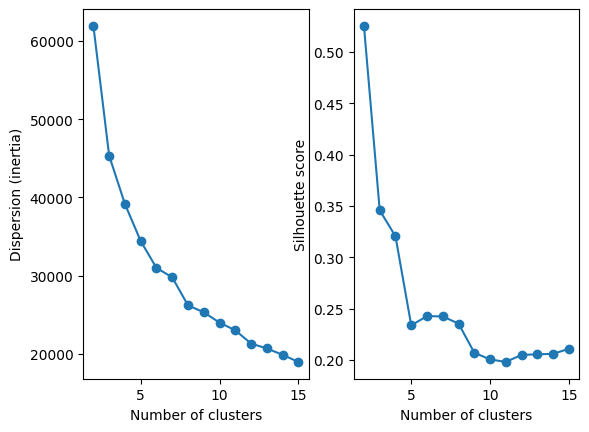

In [71]:
plot_inertia_and_silhouette(eng_filtered_st)

In [72]:
# K-Means (segunda ronda) — Standard Scaler
for k in [2, 3, 4]:
    model = KMeans(n_clusters=k, random_state=42)
    eng_filtered[f'st2_km_cluster{k}'] = model.fit_predict(eng_filtered_st)

In [73]:
for k in [2, 3, 4]:
    tmp = eng_filtered.copy()
    tmp[f'st2_km_cluster{k}'] = eng_filtered[f'st2_km_cluster{k}']

    print(f"\nK-Means (Standard) — k = {k}")
    display(
        groupby_mean(
            tmp,
            f'st2_km_cluster{k}',
            n_features=5
        )
    )



K-Means (Standard) — k = 2


st2_km_cluster2,0,1
Days_in_prog,376.094603,1496.920954
RecencyInMonths,3.875657,1.501234
Flights_per_day,0.065926,0.181132
PctFlightsWithCompanions,0.265221,0.249337
PctPointsSpent,0.320174,0.300042
mm_scaled_ward_cluster4,1.113565,2.335128



K-Means (Standard) — k = 3


st2_km_cluster3,0,1,2
Days_in_prog,359.893316,1532.885282,637.529328
RecencyInMonths,1.670810,1.501799,16.698766
Flights_per_day,0.072879,0.182411,0.071611
PctFlightsWithCompanions,0.264669,0.248858,0.266124
PctPointsSpent,0.319777,0.300252,0.307708
mm_scaled_ward_cluster4,1.121071,2.358080,1.467811



K-Means (Standard) — k = 4


st2_km_cluster4,0,1,2,3
Days_in_prog,905.354007,1936.320583,631.031519,304.364269
RecencyInMonths,1.507493,1.513314,16.702875,1.698960
Flights_per_day,0.176567,0.180077,0.071593,0.051792
PctFlightsWithCompanions,0.245263,0.253057,0.265932,0.268261
PctPointsSpent,0.297030,0.302690,0.309883,0.326370
mm_scaled_ward_cluster4,2.527928,2.023688,1.468481,1.025812


#### Choosing (K) — Second Round (Standard Scaled)

After removing non-travelers, we re-applied K-Means on the remaining customers.

* **K = 2** produces only a coarse split (high vs. lower engagement), losing nuance.
* **K = 4** starts to fragment clusters into groups that are very similar and harder to interpret.
* **K = 3** provides the most meaningful structure:

  * one cluster with **very long tenure and higher activity**,
  * one cluster with **moderate tenure and regular usage**,
  * one cluster with **high recency (returning customers)**.

This balance between interpretability and separation makes **K = 3** the preferred solution for the second stage.

#### Cluster evaluation — Robust Scaled features

We repeated the evaluation using **robust-scaled features**, which down-weight the effect of outliers.

* Inertia decreases smoothly with no sharp elbow.
* Silhouette is highest at **K = 2**, and then drops and stabilizes at lower values.

This indicates that:

* **K = 2 and K = 3** capture most of the structure,
* larger values mainly fragment clusters without improving separation.

We keep both values as candidates and compare them using cluster profiles and UMAP visualisation.

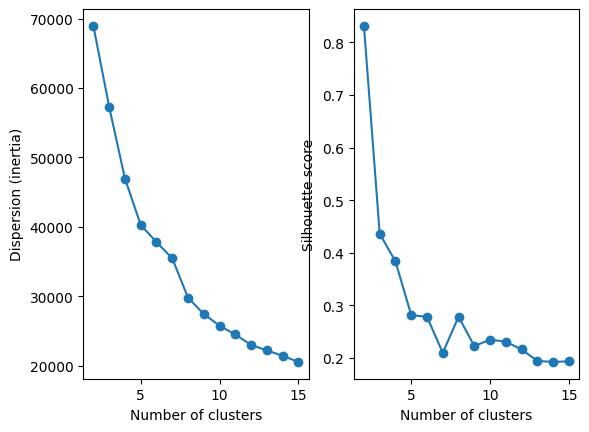

In [74]:
plot_inertia_and_silhouette(eng_filtered_rb)

In [75]:
# K-Means (segunda ronda) — Robust Scaler
for k in [2, 3]:
    model = KMeans(n_clusters=k, random_state=42)
    eng_filtered[f'rb2_km_cluster{k}'] = model.fit_predict(eng_filtered_rb)


In [76]:
for k in [2, 3]:
    tmp = eng_filtered.copy()
    tmp[f'rb2_km_cluster{k}'] = eng_filtered[f'rb2_km_cluster{k}']

    print(f"\nK-Means (Robust) — k = {k}")
    display(
        groupby_mean(
            tmp,
            f'rb2_km_cluster{k}',
            n_features=5
        )
    )



K-Means (Robust) — k = 2


rb2_km_cluster2,0,1
Days_in_prog,1168.834453,648.851656
RecencyInMonths,1.524701,16.144843
Flights_per_day,0.148431,0.074406
PctFlightsWithCompanions,0.253831,0.264324
PctPointsSpent,0.306312,0.308066
mm_scaled_ward_cluster4,1.974382,1.471523



K-Means (Robust) — k = 3


rb2_km_cluster3,0,1,2
Days_in_prog,1173.056895,628.478458,726.457732
RecencyInMonths,1.459664,19.398557,9.945406
Flights_per_day,0.148974,0.056921,0.100427
PctFlightsWithCompanions,0.253771,0.272573,0.254888
PctPointsSpent,0.306496,0.310860,0.299478
mm_scaled_ward_cluster4,1.977789,1.435374,1.581443


#### Choosing K (second round — robust scaling)

After removing non-travellers, we re-clustered the remaining customers using
Robust-Scaled features.

Comparing (K = 2) and (K = 3):

* **K = 2** clearly separates highly engaged customers from low-engagement ones.
* **K = 3** only splits the low-engagement group into two very similar segments,
  without adding meaningful behavioural differences.

Because it provides a simpler and more interpretable segmentation,
we retain **K = 2 as the preferred solution** for this second step.

#### Ward clustering — second round (after removing non-travellers)

We inspected the Ward dendrogram on the filtered dataset.
Two clear height “jumps” appear:

* the first separation happens around **K = 2**,
* a secondary, meaningful split appears at **K = 3**.

Beyond (K > 3), merges occur at very small distances, suggesting those splits
are minor refinements rather than distinct behavioural groups.

Therefore, we retain **K = 2 and K = 3 as candidates** and compare their
cluster profiles next.

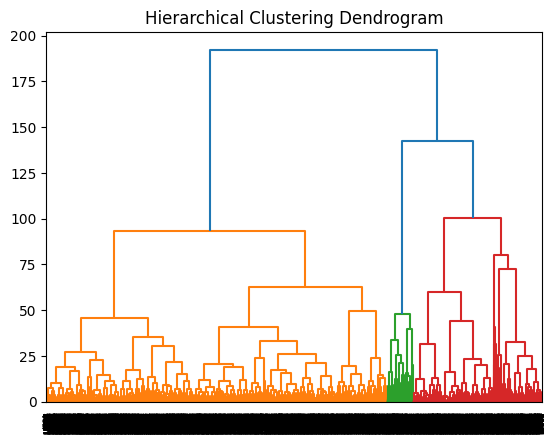

In [77]:
plot_dendrogram(eng_filtered_st, 'ward')

In [78]:
# Ward clustering — filtered engagement data (Standard scaled)
for k in [2, 3]:
    eng_filtered[f'st2_ward_cluster{k}'] = AgglomerativeClustering(
        linkage='ward',
        n_clusters=k
    ).fit_predict(eng_filtered_st)


In [79]:
# Inspect cluster profiles (Ward, second round)
for k in [2, 3]:
    tmp = eng_filtered.copy()
    tmp[f'st2_ward_cluster{k}'] = eng_filtered[f'st2_ward_cluster{k}']

    print(f"\nWard (Standard) — k = {k}")
    display(
        groupby_mean(
            tmp,
            f'st2_ward_cluster{k}',
            n_features=5
        )
    )



Ward (Standard) — k = 2


st2_ward_cluster2,0,1
Days_in_prog,399.971211,1478.126313
RecencyInMonths,3.891771,1.510969
Flights_per_day,0.065822,0.180354
PctFlightsWithCompanions,0.256627,0.253327
PctPointsSpent,0.325506,0.297781
mm_scaled_ward_cluster4,1.169771,2.301031



Ward (Standard) — k = 3


st2_ward_cluster3,0,1,2
Days_in_prog,360.866667,1478.126313,593.523929
RecencyInMonths,1.625247,1.510969,15.110206
Flights_per_day,0.064597,0.180354,0.071886
PctFlightsWithCompanions,0.258200,0.253327,0.248842
PctPointsSpent,0.343765,0.297781,0.235130
mm_scaled_ward_cluster4,1.121628,2.301031,1.408060


#### Choosing K for Ward clustering (second round)

After removing non-travellers, the Ward solutions became much clearer:

* **K = 2** separates customers mainly by *engagement intensity*
  (low vs. high tenure / flights).
* **K = 3** adds one extra group, but it mostly splits the lower-engagement
  customers into two very similar segments.

The cluster means show that the third group does not introduce a new behavioral
pattern — it simply refines the same low-activity profile.

For interpretability and stability, we therefore keep **K = 2** for the Ward
solution in this round.

#### Ward clustering (Robust-scaled) — choosing K

The Ward dendrogram on the robust-scaled data shows one dominant split:

* **K = 2**: separates customers into clearly distinct groups.
* **K = 3**: introduces one smaller branch, but still along the same
  engagement gradient.

Because the structure is simple and hierarchical, we evaluate **K = 2 and K = 3** as the most reasonable candidates.

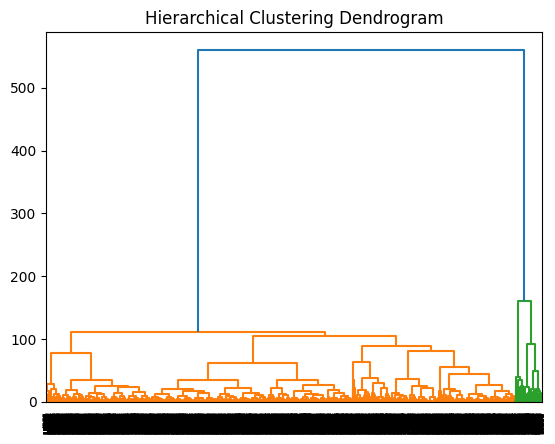

In [80]:
plot_dendrogram(eng_filtered_rb, 'ward')

In [81]:
# Ward clustering — filtered engagement data (Robust scaled)
for k in [2, 3]:
    eng_filtered[f'rb2_ward_cluster{k}'] = AgglomerativeClustering(
        linkage='ward',
        n_clusters=k
    ).fit_predict(eng_filtered_rb)


In [82]:
# Inspect cluster profiles (Ward, robust — second round)
for k in [2, 3]:
    tmp = eng_filtered.copy()
    tmp[f'rb2_ward_cluster{k}'] = eng_filtered[f'rb2_ward_cluster{k}']

    print(f"\nWard (Robust) — k = {k}")
    display(
        groupby_mean(
            tmp,
            f'rb2_ward_cluster{k}',
            n_features=5
        )
    )



Ward (Robust) — k = 2


rb2_ward_cluster2,0,1
Days_in_prog,657.748157,1170.463849
RecencyInMonths,15.543002,1.498791
Flights_per_day,0.077019,0.148587
PctFlightsWithCompanions,0.262756,0.253877
PctPointsSpent,0.302070,0.306644
mm_scaled_ward_cluster4,1.493857,1.975181



Ward (Robust) — k = 3


rb2_ward_cluster3,0,1,2
Days_in_prog,1170.463849,671.587189,626.884921
RecencyInMonths,1.498791,12.927888,21.375123
Flights_per_day,0.148587,0.094384,0.038291
PctFlightsWithCompanions,0.253877,0.262228,0.263934
PctPointsSpent,0.306644,0.298166,0.310775
mm_scaled_ward_cluster4,1.975181,1.530249,1.412698


#### Ward (Robust) — choosing the final K

After re-clustering the filtered dataset with Ward (robust-scaled), we compared:

* **K = 2** — a clean split between

  * long-tenure, high-activity customers
  * shorter-tenure, lower-activity customers.

* **K = 3** — introduces a third group, but it mainly splits the
  higher-engagement segment into two very similar sub-clusters,
  without adding clear business meaning.

Because **K = 2** preserves the main behavioral separation while keeping the solution simple and interpretable,
we retain **Ward (Robust) with K = 2** for this stage.

#### Cluster Visualization 2

#### Cluster Visualisation — Round 2 (after removing Non-Travelers)

With the inactive customers removed, we re-clustered the remaining base and
focused only on the most meaningful solutions identified earlier:

* **K-Means (Standard scaled)**: (K = 3)
* **K-Means (Robust scaled)**: (K = 2)
* **Ward hierarchical (Standard)**: (K = 2)
* **Ward hierarchical (Robust)**: (K = 2)

These values come from the inertia/silhouette diagnostics and dendrogram
structure: they capture the main engagement differences without creating
unnecessary small clusters.

We now project these models into **2D with UMAP**.
UMAP does *not* influence clustering — it simply helps us see whether the
segments form compact, well-separated groups and whether the different methods
are telling a consistent behavioural story.

In [83]:
cluster_filter2 = [
    'st2_km_cluster3',
    'rb2_km_cluster2',
    'st2_ward_cluster2',
    'rb2_ward_cluster2'
]

In [84]:
eng_umap2 = eng_filtered.copy()

for c in cluster_filter2:
    eng_umap2[c] = eng_filtered[c]


cols_to_keep = engagement_features + cluster_filter2
eng_umap2 = eng_umap2[cols_to_keep]


In [85]:
[col for col in eng_umap2.columns if "km" in col or "ward" in col]

['st2_km_cluster3',
 'rb2_km_cluster2',
 'st2_ward_cluster2',
 'rb2_ward_cluster2']

In [86]:
[col for col in eng_umap2.columns]

['Days_in_prog',
 'RecencyInMonths',
 'Flights_per_day',
 'PctFlightsWithCompanions',
 'PctPointsSpent',
 'st2_km_cluster3',
 'rb2_km_cluster2',
 'st2_ward_cluster2',
 'rb2_ward_cluster2']

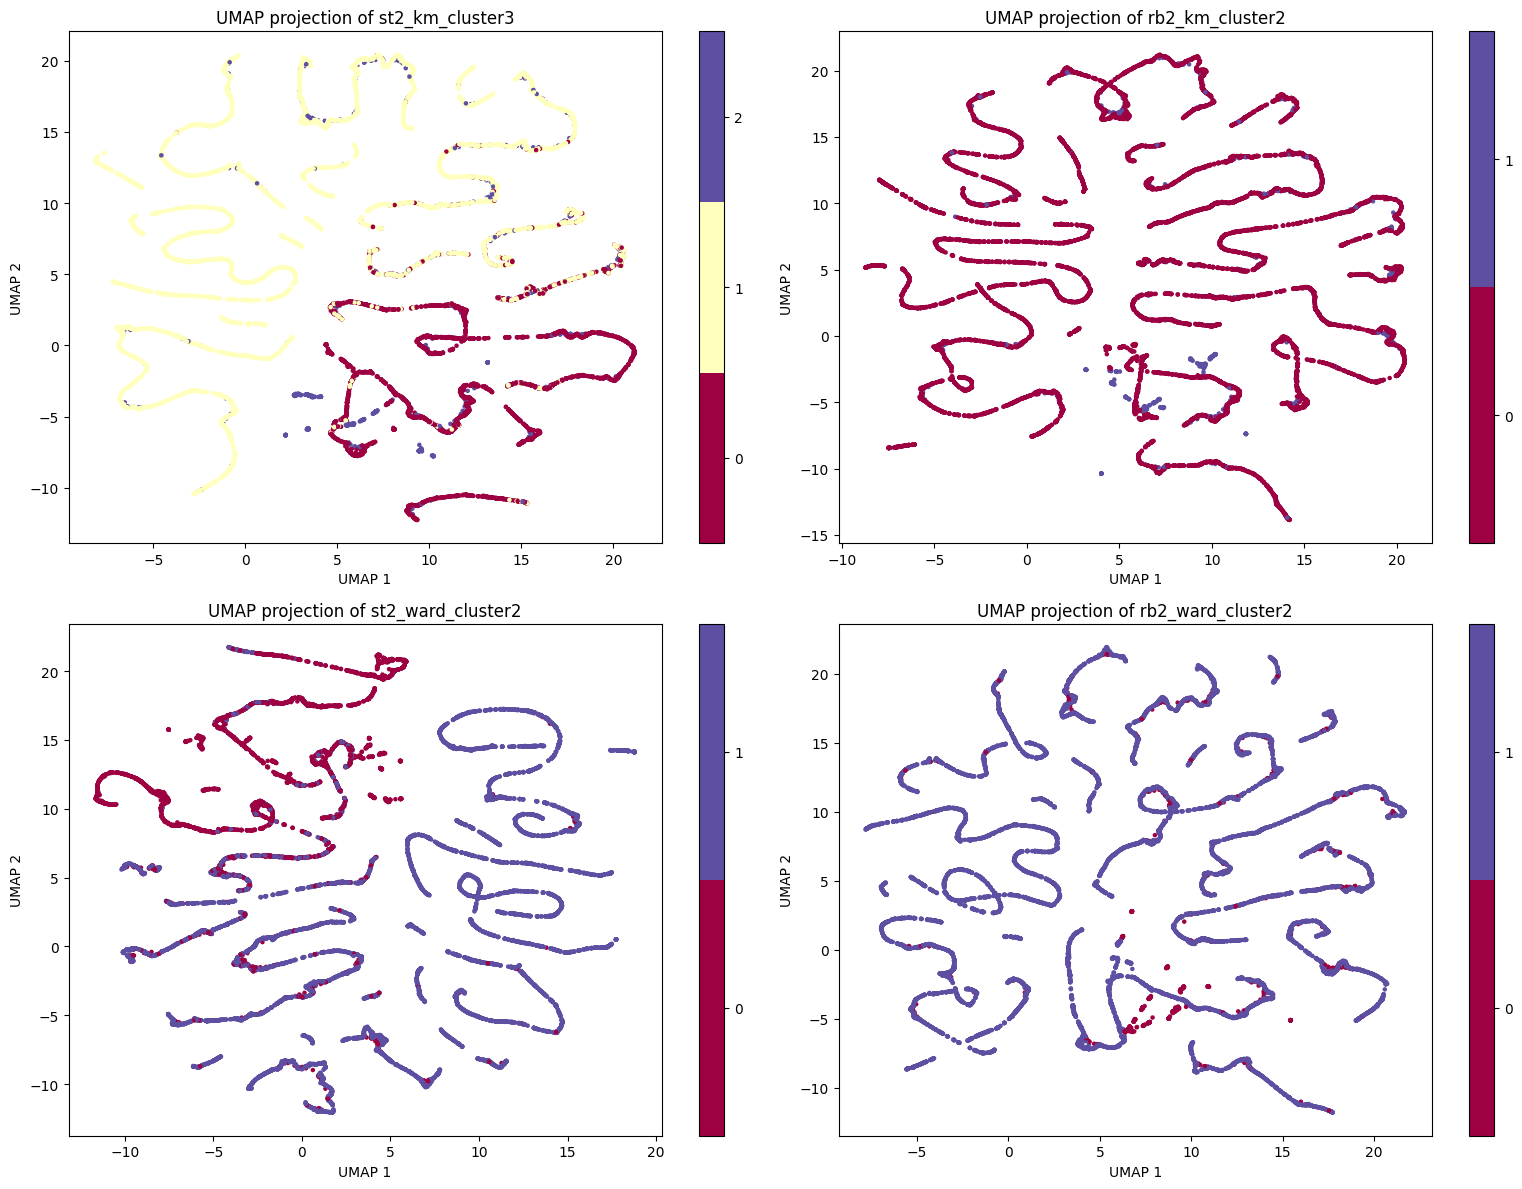

In [87]:
plot_umap_projections(eng_umap2, cluster_filter2)

In [88]:
for c in ['st2_km_cluster3', 'st2_ward_cluster2']:
    tmp = eng_filtered.copy()
    print(f"\n>>> {c}")
    display(groupby_mean(tmp, c, n_features=5))



>>> st2_km_cluster3


st2_km_cluster3,0,1,2
Days_in_prog,359.893316,1532.885282,637.529328
RecencyInMonths,1.670810,1.501799,16.698766
Flights_per_day,0.072879,0.182411,0.071611
PctFlightsWithCompanions,0.264669,0.248858,0.266124
PctPointsSpent,0.319777,0.300252,0.307708
mm_scaled_ward_cluster4,1.121071,2.358080,1.467811



>>> st2_ward_cluster2


st2_ward_cluster2,0,1
Days_in_prog,399.971211,1478.126313
RecencyInMonths,3.891771,1.510969
Flights_per_day,0.065822,0.180354
PctFlightsWithCompanions,0.256627,0.253327
PctPointsSpent,0.325506,0.297781
mm_scaled_ward_cluster4,1.169771,2.301031


Interpreting the 3-cluster KM solution

The 3-cluster K-Means model revealed one segment with a very distinct profile:

very old program tenure

few flights recently

still uses points occasionally

This group behaves like dormant travelers: customers who used to be active,
but whose current engagement is low.

The remaining clusters showed more typical travelling patterns, with higher and
more regular activity levels.

This confirms that the 3-cluster solution provides a meaningful separation
between active travelers and dormant travelers, which is useful for the
next refinement step.

#### Cluster Extraction — Step 2 (removing dormant travelers)

From the 3-cluster K-Means model on the filtered base,
Cluster **2** corresponded to **dormant travelers**:

* long historical relationship with the program
* low current flight frequency
* moderate points usage

Since our next objective is to study **active travelers only**, we:

1. isolated this cluster as `dormant_travelers`, and
2. created a new dataset `eng_round3` excluding them.

This allows the following round of clustering to focus purely on **currently
engaged customers**, revealing more granular behavioural patterns inside that
group.

In [89]:
cluster_to_remove = 2
eng_filtered2 = eng_filtered[eng_filtered['st2_km_cluster3'] != cluster_to_remove]

In [90]:
dormant_travelers = eng_filtered[eng_filtered['st2_km_cluster3'] == cluster_to_remove]

In [91]:
print(dormant_travelers.shape)
print(eng_filtered2.shape)

(699, 15)
(14499, 15)


In [92]:
eng_filtered2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14499 entries, 100018 to 999986
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Days_in_prog              14499 non-null  float64
 1   RecencyInMonths           14499 non-null  float64
 2   Flights_per_day           14499 non-null  float64
 3   PctFlightsWithCompanions  14499 non-null  float64
 4   PctPointsSpent            14499 non-null  float64
 5   mm_scaled_ward_cluster4   14499 non-null  int64  
 6   st2_km_cluster2           14499 non-null  int32  
 7   st2_km_cluster3           14499 non-null  int32  
 8   st2_km_cluster4           14499 non-null  int32  
 9   rb2_km_cluster2           14499 non-null  int32  
 10  rb2_km_cluster3           14499 non-null  int32  
 11  st2_ward_cluster2         14499 non-null  int64  
 12  st2_ward_cluster3         14499 non-null  int64  
 13  rb2_ward_cluster2         14499 non-null  int64  
 14  rb2_w

In [93]:
eng_round3 = eng_filtered2[engagement_features].copy()

In [94]:
[col for col in eng_round3.columns]

['Days_in_prog',
 'RecencyInMonths',
 'Flights_per_day',
 'PctFlightsWithCompanions',
 'PctPointsSpent']

### <h3 style="color: #333333; background-color: #b0cece; text-align: center; padding: 6px; font-family: 'Arial';">(3) Third-Examination</h3>

#### Re-Scaling Data 3

In [95]:
eng_round3

,Days_in_prog,RecencyInMonths,Flights_per_day,PctFlightsWithCompanions,PctPointsSpent
Loyalty#,,,,,
100018,874.0,1.018397,0.209954,0.213136,0.387873
100102,2122.0,1.018397,0.226210,0.234154,0.553345
100140,884.0,2.003942,0.197991,0.249077,0.113353
100214,1242.0,1.018397,0.102557,0.178094,0.354109
100272,1816.0,2.003942,0.170228,0.284335,0.253564
...,...,...,...,...,...
999758,131.0,1.018397,0.014612,0.250000,0.682669
999902,1681.0,3.022339,0.243927,0.284538,0.172142
999940,523.0,1.018397,0.079909,0.320000,0.235584


In [96]:
eng_round3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14499 entries, 100018 to 999986
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Days_in_prog              14499 non-null  float64
 1   RecencyInMonths           14499 non-null  float64
 2   Flights_per_day           14499 non-null  float64
 3   PctFlightsWithCompanions  14499 non-null  float64
 4   PctPointsSpent            14499 non-null  float64
dtypes: float64(5)
memory usage: 679.6 KB


In [97]:
# Standard & Robust scaling — Round 3
st_scaler = StandardScaler().set_output(transform="pandas")
rb_scaler = RobustScaler().set_output(transform="pandas")

eng_round3_st = st_scaler.fit_transform(eng_round3)
eng_round3_rb = rb_scaler.fit_transform(eng_round3)


In [98]:
eng_round3_st.head()

,Days_in_prog,RecencyInMonths,Flights_per_day,PctFlightsWithCompanions,PctPointsSpent
Loyalty#,,,,,
100018,-0.407850,-0.487632,0.943469,-0.362008,0.244567
100102,1.327136,-0.487632,1.192143,-0.174827,0.740896
100140,-0.393947,0.408867,0.760457,-0.041925,-0.578846
100214,0.103749,-0.487632,-0.699454,-0.674079,0.143293
100272,0.901731,0.408867,0.335755,0.272066,-0.158287


In [99]:
eng_round3_rb.head()

,Days_in_prog,RecencyInMonths,Flights_per_day,PctFlightsWithCompanions,PctPointsSpent
Loyalty#,,,,,
100018,-0.202640,0.0,0.604308,-0.265501,0.384513
100102,0.766304,0.0,0.806122,-0.097264,0.847658
100140,-0.194876,1.0,0.455782,0.022189,-0.383847
100214,0.083075,0.0,-0.729025,-0.545991,0.290010
100272,0.528727,1.0,0.111111,0.304404,0.008593


#### Cluster Modelling 3

Using the **standard-scaled dataset**:

* **Inertia** decreases smoothly with no clear elbow.
* **Silhouette scores** drop noticeably after **K = 2** and remain relatively low afterward.

This suggests that small values of **K (around 2–3)** capture most of the meaningful structure, while larger K mainly add complexity without clear separation benefits.

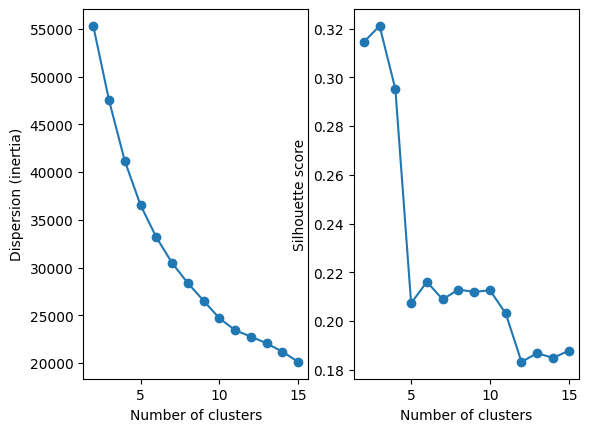

In [100]:
plot_inertia_and_silhouette(eng_round3_st)

#### Cluster evaluation — Robust Scaled (Round 3)

With the **robust-scaled features**:

* **Inertia** again declines gradually.
* **Silhouette** is highest at **K = 2** and steadily worsens as K increases.

Here, **K = 2 clearly stands out** as the most stable and interpretable solution.

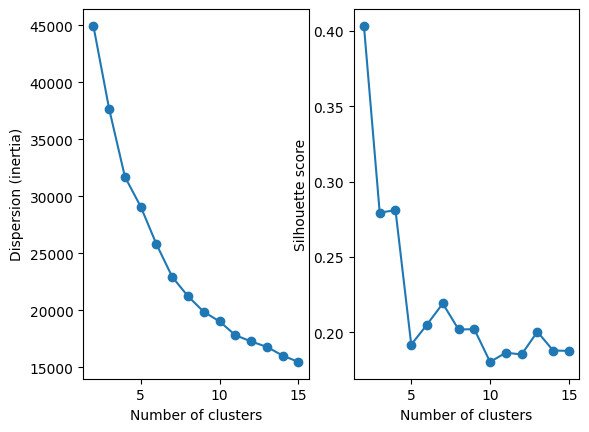

In [101]:
plot_inertia_and_silhouette(eng_round3_rb)

#### Dendrogram — Standard Scaled (Ward linkage)

The Ward dendrogram on the standard-scaled data shows:

* One dominant split forming **two major branches**.
* Additional cuts (K ≥ 3) start fragmenting the tree into smaller, less meaningful groups.

This supports **K ≈ 2** as the most natural hierarchical cut.

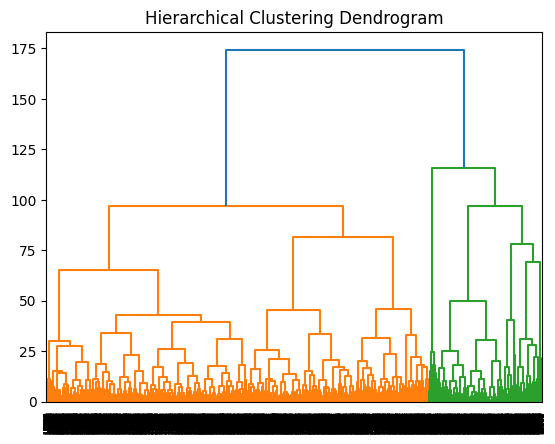

In [102]:
plot_dendrogram(eng_round3_st, 'ward')

#### Dendrogram — Robust Scaled (Ward linkage)

For the robust-scaled dendrogram:

* A strong top-level division again appears at **two clusters**.
* Further splits tend to produce unbalanced or noisy sub-groups.

Once more, **K = 2** emerges as the most interpretable segmentation level.

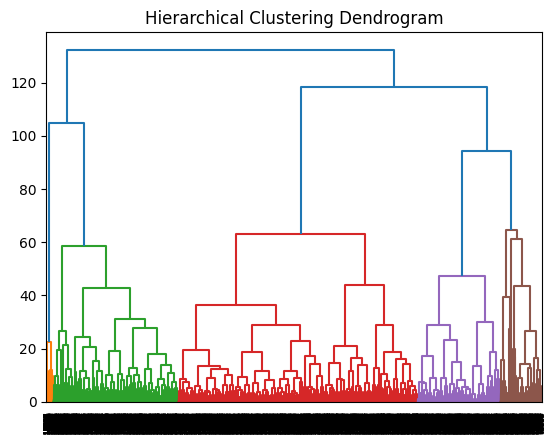

In [103]:
plot_dendrogram(eng_round3_rb, 'ward')

#### Hierarchical clustering (refinement step)

We now re-apply hierarchical clustering — but only on the customers who remain
after removing:

1. Non-travelers (Round 1)
2. Dormant / very low-activity travelers (Round 2)

The diagnostics for this round were very consistent:

* Both **standard-scaled** and **robust-scaled** dendrograms show a clear
  dominant split into **two main groups**.
* Silhouette curves confirm that increasing K beyond 2 does **not** create
  better-separated clusters.

At this stage, choosing **small K values is intentional**.
We are refining the segmentation step-by-step, uncovering structure gradually
instead of forcing many artificial micro-clusters all at once.

Therefore, we proceed with:

* **Ward (Standard)** → K = 2
* **Ward (Robust)** → K = 2

and compare the resulting segment profiles.

In [104]:
# Ward clustering — Round 3 (Standard & Robust)
eng_round3['st3_ward_cluster2'] = AgglomerativeClustering(
    linkage='ward',
    n_clusters=2
).fit_predict(eng_round3_st)

eng_round3['rb3_ward_cluster2'] = AgglomerativeClustering(
    linkage='ward',
    n_clusters=2
).fit_predict(eng_round3_rb)


In [105]:
# Inspect cluster profiles — Ward (Round 3)
for label in ['st3_ward_cluster2', 'rb3_ward_cluster2']:
    
    tmp = eng_round3.copy()
    tmp[label] = eng_round3[label]

    print(f"\nWard — {label}")
    display(
        groupby_mean(
            tmp,
            label,
            n_features=5
        )
    )



Ward — st3_ward_cluster2


st3_ward_cluster2,0,1
Days_in_prog,328.084951,1414.295992
RecencyInMonths,1.859330,1.464770
Flights_per_day,0.053403,0.176194
PctFlightsWithCompanions,0.265803,0.250249
PctPointsSpent,0.332801,0.298550
rb3_ward_cluster2,0.154126,0.300455



Ward — rb3_ward_cluster2


rb3_ward_cluster2,0,1
Days_in_prog,1115.797459,1308.822406
RecencyInMonths,1.096539,2.810390
Flights_per_day,0.144061,0.159851
PctFlightsWithCompanions,0.254077,0.252985
PctPointsSpent,0.306875,0.304858
st3_ward_cluster2,0.737600,0.868869


#### K-Means refinement (visual validation)

Next, we also apply K-Means on the refined dataset to see whether a simpler
partition emerges consistently across algorithms

In [106]:
# K-Means — Round 3 (Standard & Robust)
kmeans_st3 = KMeans(n_clusters=2, random_state=42).fit(eng_round3_st)
eng_round3['st3_km_cluster2'] = kmeans_st3.predict(eng_round3_st)

kmeans_rb3 = KMeans(n_clusters=2, random_state=42).fit(eng_round3_rb)
eng_round3['rb3_km_cluster2'] = kmeans_rb3.predict(eng_round3_rb)


In [107]:
# Inspect cluster profiles — K-Means (Round 3)
for label in ['st3_km_cluster2', 'rb3_km_cluster2']:
    
    tmp = eng_round3.copy()
    tmp[label] = eng_round3[label]

    print(f"\nK-Means — {label}")
    display(
        groupby_mean(
            tmp,
            label,
            n_features=5
        )
    )


K-Means — st3_km_cluster2


st3_km_cluster2,0,1
Days_in_prog,1528.944350,366.025510
RecencyInMonths,1.466132,1.750232
Flights_per_day,0.182461,0.072525
PctFlightsWithCompanions,0.248869,0.264681
PctPointsSpent,0.300633,0.318976
st3_ward_cluster2,0.992894,0.284605



K-Means — rb3_km_cluster2


rb3_km_cluster2,0,1
Days_in_prog,1176.065915,1098.921665
RecencyInMonths,1.242778,4.008467
Flights_per_day,0.150160,0.133481
PctFlightsWithCompanions,0.253467,0.256287
PctPointsSpent,0.304327,0.322155
st3_ward_cluster2,0.783521,0.687271


In [108]:
cluster_filter3 = [
    'st3_km_cluster2',
    'rb3_km_cluster2',
    'st3_ward_cluster2',
    'rb3_ward_cluster2'
]


In [109]:
eng_umap3 = eng_round3.copy()

for c in cluster_filter3:
    eng_umap3[c] = eng_round3[c]

# Keep only engagement features + these clusters
cols_to_keep = engagement_features + cluster_filter3
eng_umap3 = eng_umap3[cols_to_keep]


In [110]:
[col for col in eng_umap3.columns]

['Days_in_prog',
 'RecencyInMonths',
 'Flights_per_day',
 'PctFlightsWithCompanions',
 'PctPointsSpent',
 'st3_km_cluster2',
 'rb3_km_cluster2',
 'st3_ward_cluster2',
 'rb3_ward_cluster2']

We then project all clustering solutions into UMAP space to visually compare
their separation:

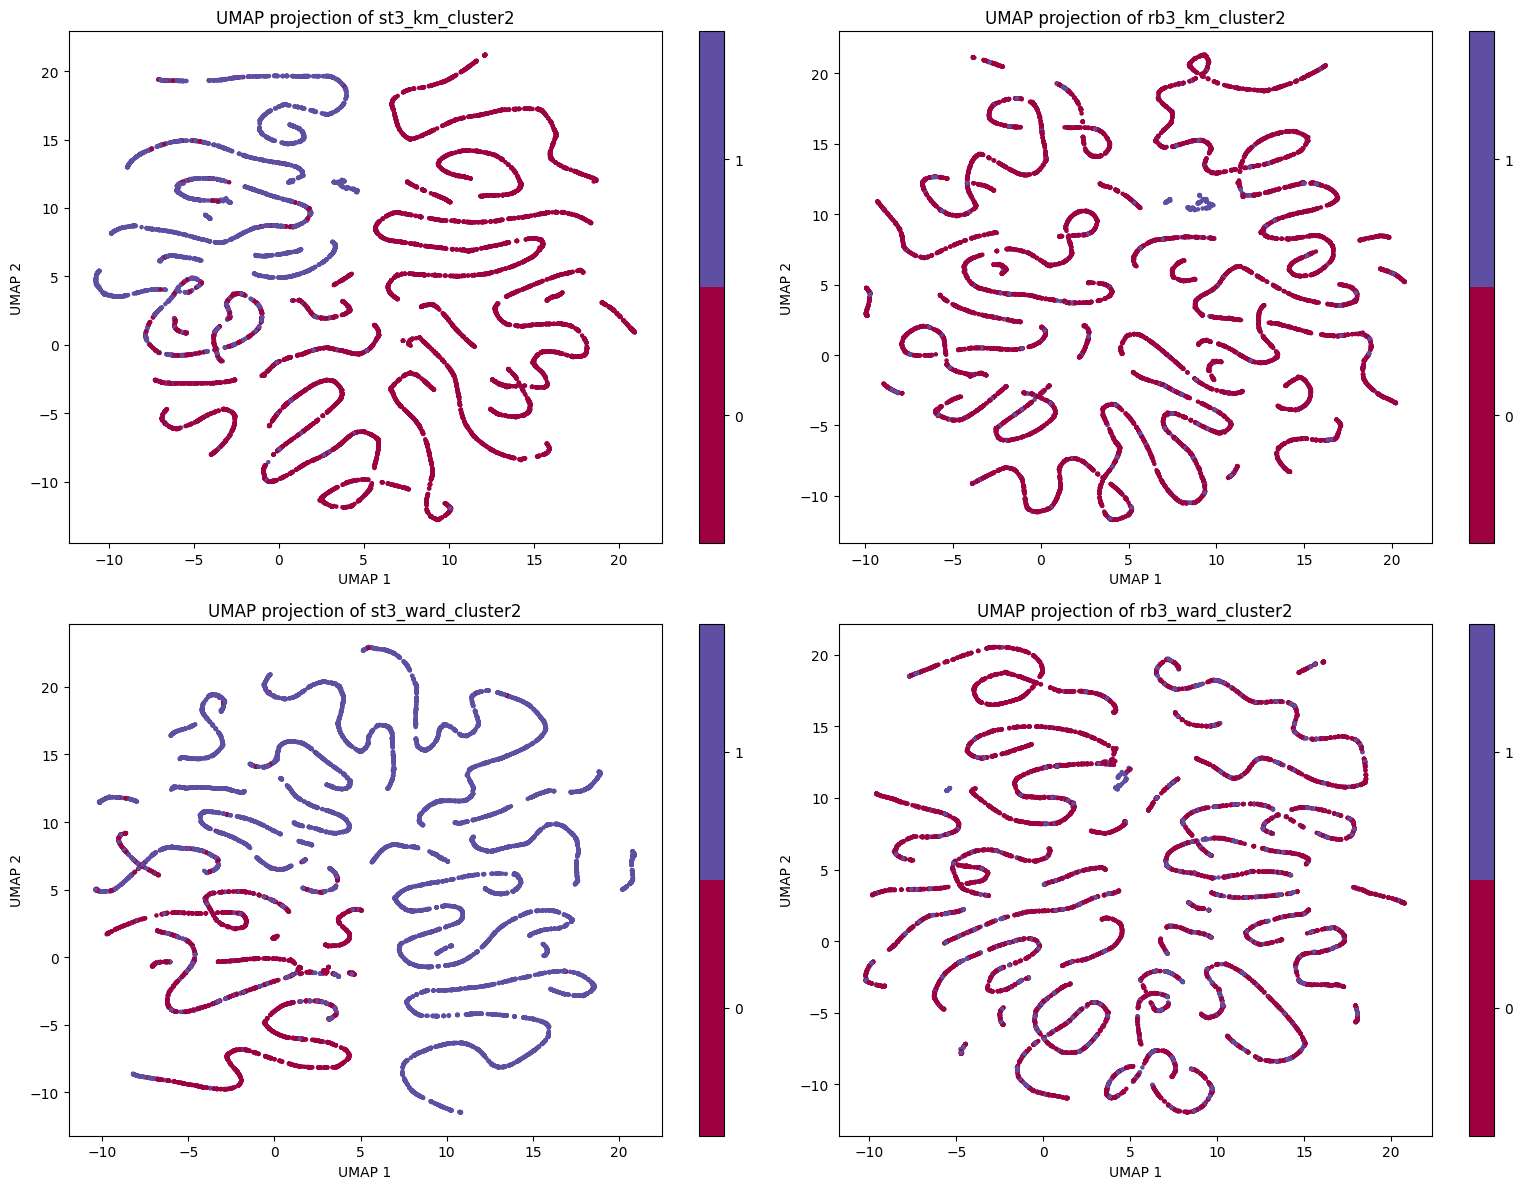

In [111]:
plot_umap_projections(eng_umap3, cluster_filter3)

We selected the Standard-scaled K-Means (K = 2) model.
Among all candidates, it produced the cleanest UMAP separation and the clearest
behavioural contrast in the cluster means.

* **Cluster 1**

  * much shorter program tenure
  * much lower flight frequency
  * still spend occasionally, but irregular
* **Cluster 0**

  * long tenure
  * regular flight activity
  * consistently using points

##### Cluster Interpretation — Round 3 (K-Means, Standard)

The chosen 2-cluster solution reveals a final, meaningful split:

* **Cluster 0 — “Active Regular Travelers”**
  Customers who remain consistently engaged: longer tenure, frequent flying,
  and steady points redemption.

* **Cluster 1 — “Low-Engagement / Light Users”**
  Customers who fly occasionally, participate less, and show weaker loyalty
  signals.

This final refinement helps distinguish customers who are still committed to
the program from those whose participation remains marginal.

#### Cluster Extraction 3

In [125]:
# Final split
low_engagement = eng_round3[eng_round3['st3_km_cluster2'] == 1]
active_travelers = eng_round3[eng_round3['st3_km_cluster2'] == 0]

# Remove both -> nothing left to cluster
eng_final = eng_round3[~eng_round3['st3_km_cluster2'].isin([0, 1])]

eng_final.shape


(0, 9)

In [126]:
people['segment'] = 'Unassigned'

people.loc[non_travelers.index, 'segment'] = 'Non_Travelers'
people.loc[active_travelers.index, 'segment'] = 'Active_Travelers'
people.loc[dormant_travelers.index, 'segment'] = 'Dormant_Travelers'
people.loc[low_engagement.index, 'segment'] = 'Low_Engagement'


The result (eng_final) is empty, meaning that all remaining customers
were already classified into meaningful segments at this stage.
No additional clustering is necessary for this branch.

In [127]:
eng_final

,Days_in_prog,RecencyInMonths,Flights_per_day,PctFlightsWithCompanions,PctPointsSpent,st3_ward_cluster2,rb3_ward_cluster2,st3_km_cluster2,rb3_km_cluster2
Loyalty#,,,,,,,,,


In [128]:
people['segment'].value_counts()

segment
Active_Travelers     9991
Low_Engagement       4508
Non_Travelers        1517
Dormant_Travelers     699
Name: count, dtype: int64

In [129]:
people['segment'].value_counts().sum()

16715

In [130]:
(people['segment'] == "Unassigned").sum()

0

In [131]:
people[['segment'] + engagement_features].groupby('segment').mean()

,Days_in_prog,RecencyInMonths,Flights_per_day,PctFlightsWithCompanions,PctPointsSpent
segment,,,,,
Active_Travelers,1528.944350,1.466132,0.182461,0.248869,0.300633
Dormant_Travelers,637.529328,16.698766,0.071611,0.266124,0.307708
Low_Engagement,366.025510,1.750232,0.072525,0.264681,0.318976
Non_Travelers,582.224786,999.000000,0.001990,0.003088,0.002836


# <span style="color:#0097b2">3. Final Customer Segmentation Assignment</span>
[Back to TOC](#toc)

After completing all clustering rounds, each customer is assigned to one of the
final engagement-based segments:

* **Non_Travelers** – customers who are enrolled in the program but never fly.
* **Dormant_Travelers** – previously active customers whose activity has dropped close to zero.
* **Low_Engagement** – occasional travelers with limited and irregular program use.
* **Active_Travelers** – consistently engaged travelers with regular activity and point usage.

We created the segment column and mapped customers to their corresponding group:

Result:

| Segment           | Customers |
| ----------------- | --------: |
| Active_Travelers  |     9,991 |
| Low_Engagement    |     4,508 |
| Non_Travelers     |     1,517 |
| Dormant_Travelers |       699 |

Each customer now belongs to **exactly one** clearly interpretable behavioral group.

This confirms that our segmentation meaningfully splits the population into
distinct groups (loyal, at-risk, inactive and non-travelers).

To make the segment usable in downstream analytics and modeling, we convert the
categorical label into one-hot encoded variables:

In [132]:
segment_dummies = pd.get_dummies(
    people['segment'],
    prefix='seg',
    dtype=int
)

#### Append the Encoded Segments to the Dataset

We now merge the one-hot encoded segment columns back into the main dataset.

This keeps all original features while adding four new binary indicators for the
final customer segments.

In [133]:
people = pd.concat([people, segment_dummies], axis=1)

Since the segment is now represented by one-hot encoded variables, the original
categorical column is no longer needed:

In [134]:
people.drop(columns=['segment'], inplace=True)

In [135]:
people = people.loc[:, ~people.columns.str.startswith(("st_", "mm_", "rb_"))]

#### Appending Encoded Segments

We convert the categorical segment label into one-hot encoded variables and
append them to the main dataset. This preserves all original features while
adding four new binary indicators — one for each final customer segment.

Displaying `people` confirms the final structure: each row now contains
exactly one segment flag equal to 1, and 0 for the others.

**Key added columns:**

* `seg_Active_Travelers`
* `seg_Low_Engagement`
* `seg_Dormant_Travelers`
* `seg_Non_Travelers`

Each customer belongs to exactly **one** segment.

In [136]:
people

,Income,Customer Lifetime Value,EnrollmentType,rejoined_program,Days_in_prog,Cancelled_program,Enrollment_year,Enrollment_month,TotalFlights,TotalDistance,...,Location__6,Location__7,seg_Active_Travelers,seg_Dormant_Travelers,seg_Low_Engagement,seg_Non_Travelers,seg_Active_Travelers,seg_Dormant_Travelers,seg_Low_Engagement,seg_Non_Travelers
Loyalty#,,,,,,,,,,,,,,,,,,,,,
100011,34148.0,5780.18,0,0,0.0,0,2017,5,0.0,0.0,...,0,0,0,0,0,1,0,0,0,1
100012,34148.0,5780.18,0,0,0.0,0,2019,2,0.0,0.0,...,0,0,0,0,0,1,0,0,0,1
100013,34148.0,5780.18,0,0,0.0,0,2017,9,0.0,0.0,...,0,0,0,0,0,1,0,0,0,1
100014,34148.0,5780.18,0,0,0.0,0,2020,11,0.0,0.0,...,0,0,0,0,0,1,0,0,0,1
100015,34148.0,5780.18,0,0,0.0,0,2020,4,0.0,0.0,...,0,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,34148.0,5780.18,0,0,0.0,0,2020,3,0.0,0.0,...,0,0,0,0,0,1,0,0,0,1
999996,34148.0,5780.18,0,0,0.0,0,2018,9,0.0,0.0,...,0,0,0,0,0,1,0,0,0,1
999997,34148.0,5780.18,0,0,0.0,0,2020,1,0.0,0.0,...,0,0,0,0,0,1,0,0,0,1


In [137]:
people.to_csv('engagement_based_perspective_clusters.csv')

#### Summary

This perspective grouped customers using engagement signals such as:

* program tenure
* flight frequency
* recency of activity
* companion travel
* loyalty points usage

We applied clustering **iteratively**, removing clearly distinct segments at each step.

---

##### Step 1 — Identify Non-Travelers

The first pass revealed a large segment of customers who **never fly**.
They behave structurally differently, so they were isolated as:

**Non_Travelers**

---

##### Step 2 — Remove Dormant Travelers

Among remaining customers, we found a group with **past activity but almost no
recent usage**.

**Dormant_Travelers**

---

##### Step 3 — Final split of active flyers

The last clustering round separated two clear groups:

* **Low_Engagement** – occasional or irregular travelers
* **Active_Travelers** – consistent, frequent program users

After this step, no customers remained unclassified.

---

##### Final Segments

| Segment               | Meaning                                         |
| --------------------- | ----------------------------------------------- |
| **Non_Travelers**     | Enrolled, but never fly or use loyalty benefits |
| **Dormant_Travelers** | Previously active, now inactive                 |
| **Low_Engagement**    | Light / occasional travelers                    |
| **Active_Travelers**  | Regular, highly engaged members                 |

---

##### Why this matters

The segmentation is:

* simple to interpret
* behavior-driven
* stable across methods
* directly actionable

It supports strategies such as:

* onboarding for **Low_Engagement**
* re-activation for **Dormant_Travelers**
* retention programs for **Active_Travelers**
* separate handling of **Non_Travelers**